# 04_Flight_Test_Model_Calibration.ipynb

# Havacılıkta Veri Bilimcileri İçin Optimizasyon: Uçuş Testi Model Kalibrasyonu

Bu defter, 'Havacılıkta Veri Bilimcileri İçin Optimizasyon' serisinin bir parçasıdır ve uçuş test verilerini kullanarak uçak modellerinin kalibrasyonuna odaklanmaktadır. Amaç, veri odaklı modelleme, parametre tahmini, optimizasyon iş akışları, belirsizlik nicelemesi ve karar zekası gibi konuları vurgulamaktır.

## Kaynaklar



# Bölüm 1 – Giriş

Uçuş testi, bir uçağın operasyonel zarf içinde güvenli ve beklenen performansı karşıladığını doğrulamak için kritik bir aşamadır. Yeni bir hava taşıtının geliştirilmesinde, sertifikasyon sürecinde ve mevcut platformların iyileştirilmesinde vazgeçilmez bir rol oynar.

Ancak, en gelişmiş aerodinamik ve itki modelleri bile karmaşık gerçek dünya koşulları nedeniyle asla mükemmel değildir. Hava akışındaki türbülans, atmosferik değişkenlikler, üretim toleransları ve sensör gürültüsü gibi faktörler, simülasyon modelleri ile gerçek dünya performansı arasında her zaman bir fark yaratır. Bu tutarsızlıklar, modelin tahmin doğruluğunu ve güvenilirliğini azaltabilir.

Model kalibrasyonu, bu uyumsuzlukları gidermek için vazgeçilmez bir süreçtir. Uçuş testi verileri ile model tahminleri arasındaki farkı en aza indirmek amacıyla model parametrelerinin sistematik olarak ayarlanmasını içerir. Temelde, kalibrasyon, model çıktısını gerçek ölçümlere mümkün olduğunca yaklaştıran parametre setini bulmayı amaçlayan bir optimizasyon problemidir.

## Uçuş Verilerinden Karar Zekasına

Uçuş testlerinden elde edilen ham veriler, uçağın performansı hakkında değerli bilgiler içerir. Bu verileri dikkatli bir şekilde işleyerek, analiz ederek ve mevcut fizik tabanlı modellerle entegre ederek, mühendisler ve veri bilimciler daha doğru ve güvenilir uçak modelleri geliştirebilirler. Bu kalibre edilmiş modeller, tasarım döngüsünün erken aşamalarından operasyonel dağıtıma kadar mühendislik kararlarını bilgilendirmek için temel oluşturur. Optimizasyon algoritmalarını kullanarak, bu verileri eyleme dönüştürülebilir içgörülere dönüştürür ve nihayetinde güvenliği, verimliliği ve performansı artırır.

# Bölüm 2 – Kalibrasyon Problemine Genel Bakış

Uçuş test verileriyle model kalibrasyonu, fizik tabanlı bir modelin bazı parametrelerini, modelin çıktıları ile gerçek dünya ölçümleri arasındaki farkı en aza indirecek şekilde ayarlamayı içerir. Bu bölümde, basitleştirilmiş bir uçak performans modelini tanıtacak, modelin girdilerini, çıktılarını ve kalibrasyon için hedeflenen bilinmeyen parametreleri tanımlayacağız.

## Basitleştirilmiş Uçak Performans Modeli

Basit bir uçak performans modeli için aşağıdaki çıktıları ele alabiliriz:

- **Yakıt Akışı (Fuel Flow)**: Belirli uçuş koşullarında motorların tükettiği yakıt miktarı.
- **Tırmanma Hızı (Rate of Climb)**: Uçağın dikey hızlanma oranı.
- **Gerçek Hava Hızı (True Airspeed - TAS)**: Uçağın havaya göre gerçek hızı.

Bu modelin bazı temel parametreleri doğası gereği belirsizdir veya zamanla değişebilir. Kalibrasyon sürecinde optimize edeceğimiz bu belirsiz parametrelere örnekler:

- **Sürükleme Faktörü (Drag Factor)**: Uçağın aerodinamik sürüklemesini etkileyen bir katsayı.
- **İtme Verimliliği (Propulsive Efficiency)**: Motorların yakıtı itmeye dönüştürme verimliliği.
- **Yakıt Tüketim Faktörü (Fuel Consumption Factor)**: Motorun yakıtı enerjiye dönüştürme verimliliği.

## Girdiler (Inputs), Çıktılar (Outputs) ve Bilinmeyen Parametreler (Unknown Parameters)

**Model Girdileri (Ölçülen Uçuş Koşulları):**
- Ağırlık (Weight)
- İrtifa (Altitude)
- Gerçek Hava Hızı (TAS)
- Dış Hava Sıcaklığı (Outside Air Temperature)

**Model Çıktıları (Model Tahminleri):**
- Yakıt Akışı Tahmini (Predicted Fuel Flow)
- Tırmanma Hızı Tahmini (Predicted Rate of Climb)

**Bilinmeyen Parametreler (Kalibre Edilecek):**
- $P_1$: Sürükleme Faktörü
- $P_2$: İtme Verimliliği
- $P_3$: Yakıt Tüketim Faktörü

## Kalibrasyon Probleminin Matematiksel Formülasyonu

Kalibrasyon problemi, gerçek uçuş verileri ile model tahminleri arasındaki farkı en aza indiren bilinmeyen parametre setini bulmak olarak formüle edilebilir. Bu genellikle bir hedef fonksiyonu (objective function) minimize edilerek yapılır.

**Hedef Fonksiyonu: Model Hatasını Minimize Etme**

Model hatasını ölçmek için çeşitli metrikler kullanılabilir. Yaygın olarak kullanılan bir metrik, Tahmini Yakıt Akışı ve Tırmanma Hızı için **Ortalama Kare Hata (Mean Squared Error - MSE)** veya **Hata Kareleri Toplamı (Sum of Squared Errors - SSE)**'dir.

Model çıktılarımız $Y_{model}(P_1, P_2, P_3)$ ve gerçek ölçümlerimiz $Y_{gerçek}$ olmak üzere, hedef fonksiyonu $J$ şu şekilde tanımlanabilir:

$$ J(P_1, P_2, P_3) = \frac{1}{N} \sum_{i=1}^{N} \left[ (FF_{model,i} - FF_{gerçek,i})^2 + (RoC_{model,i} - RoC_{gerçek,i})^2 \right] $$

Burada:
- $N$: Veri noktalarının sayısı
- $FF_{model,i}$: $i$-inci veri noktası için modelin tahmin ettiği Yakıt Akışı
- $FF_{gerçek,i}$: $i$-inci veri noktası için ölçülen Yakıt Akışı
- $RoC_{model,i}$: $i$-inci veri noktası için modelin tahmin ettiği Tırmanma Hızı
- $RoC_{gerçek,i}$: $i$-inci veri noktası için ölçülen Tırmanma Hızı

**Optimizasyon Problemi:**

Bilinmeyen parametreleri optimize etme hedefi aşağıdaki gibidir:

$$ \min_{P_1, P_2, P_3} J(P_1, P_2, P_3) $$

Bu, belirli bir kısıt aralığında veya kısıtlamasız olarak $P_1, P_2, P_3$ parametrelerini, $J$ hedef fonksiyonunu minimum yapan değerleri bulma problemidir. Bu parametrelerin fiziksel olarak anlamlı sınırlar içinde kalması için genellikle kısıtlamalar uygulanır.

# Bölüm 3 – Sentetik Uçuş Testi Verisi Üretimi

Model kalibrasyon algoritmalarımızı geliştirmek ve test etmek için gerçekçi bir sentetik uçuş testi veri seti oluşturmak faydalıdır. Bu, algoritmaların performansını bilinen 'gerçek' parametre değerlerine karşı değerlendirmemize olanak tanır. Bu bölümde, çeşitli uçuş koşullarını ve ölçüm gürültüsünü taklit eden bir veri seti oluşturacağız.

In [ ]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Define simulation parameters
num_samples = 5000  # Number of flight data samples

# Generate Time
time = np.linspace(0, 1000, num_samples)  # 1000 seconds of flight

# Generate Altitude: Simulate a climb and cruise profile
altitude_climb_rate = 1500 / 60  # ft/sec (1500 ft/min)
altitude_climb_duration = num_samples / 3  # First third of flight is climb
altitude_cruise_altitude = 10000 # ft

altitude = np.zeros(num_samples)
altitude[:int(altitude_climb_duration)] = np.linspace(2000, altitude_cruise_altitude, int(altitude_climb_duration))
altitude[int(altitude_climb_duration):] = altitude_cruise_altitude + np.random.normal(0, 50, num_samples - int(altitude_climb_duration)) # Cruise with some variations
altitude = np.maximum(altitude, 2000) + np.random.normal(0, 20, num_samples) # Add some noise and ensure minimum

# Generate Indicated Airspeed (IAS) - typical flight speeds
ias = np.random.uniform(150, 250, num_samples) # knots

# Generate Outside Air Temperature (OAT) - decreasing with altitude
oat_sea_level = 15 # Celsius
oat_lapse_rate = 6.5 / 1000 # C/meter (approx 2C/1000ft)

oat = oat_sea_level - (altitude * 0.3048 * oat_lapse_rate) + np.random.normal(0, 2, num_samples) # Convert ft to meters

# Calculate True Airspeed (TAS) from IAS and Altitude (simplified relation)
# TAS = IAS * sqrt(rho0 / rho) where rho is air density
# rho is a function of altitude and temperature
# For simplicity, let's use a rough approximation based on altitude
tas_factor = 1 + (altitude / 10000) * 0.15 # TAS increases with altitude
tas = ias * tas_factor + np.random.normal(0, 5, num_samples) # Add noise

# Generate Aircraft Weight: Simulate fuel burn during flight
initial_weight = 60000 # lbs
fuel_burn_rate = 1000 / 3600 # lbs/sec (1000 lbs/hr)
weight = initial_weight - (time * fuel_burn_rate)
weight = np.maximum(weight, initial_weight - 20000) # Minimum weight
weight += np.random.normal(0, 100, num_samples) # Add small noise

# --- Define "True" Physics Model for Fuel Flow and Rate of Climb ---
# These are the actual underlying physics we are trying to calibrate against
# These parameters are what we will try to "find" during calibration

# True parameters for the synthetic model
true_drag_factor = 0.00005 # P1
true_propulsive_efficiency = 0.85 # P2
true_fuel_consumption_factor = 0.6 # P3

def true_fuel_flow_model(weight, tas, altitude, drag_factor, prop_efficiency, fuel_factor):
    # Simplified model for fuel flow (e.g., related to thrust and efficiency)
    # Thrust roughly balances drag in cruise
    air_density_ratio = 1 - (altitude / 45000) # Simplified, but captures altitude effect
    drag = drag_factor * air_density_ratio * tas**2
    thrust_required = drag
    fuel_flow = (thrust_required / prop_efficiency) * fuel_factor
    return fuel_flow

def true_roc_model(weight, tas, altitude, drag_factor, prop_efficiency, fuel_factor):
    # Simplified model for rate of climb (e.g., related to excess power)
    # Excess power = (Thrust - Drag) * TAS
    # RoC = Excess Power / Weight
    air_density_ratio = 1 - (altitude / 45000)
    drag = drag_factor * air_density_ratio * tas**2
    thrust_available = 10000 # Simplified constant thrust available
    excess_thrust = thrust_available - drag
    roc = (excess_thrust * tas) / weight
    return roc * 0.1 # Scale to more realistic RoC values (ft/min)

# Calculate true (noiseless) outputs
true_fuel_flow = true_fuel_flow_model(weight, tas, altitude, true_drag_factor, true_propulsive_efficiency, true_fuel_consumption_factor)
true_rate_of_climb = true_roc_model(weight, tas, altitude, true_drag_factor, true_propulsive_efficiency, true_fuel_consumption_factor)

# Add realistic noise to outputs to simulate measurement errors
fuel_flow = true_fuel_flow + np.random.normal(0, 10, num_samples) # Lbs/hr
rate_of_climb = true_rate_of_climb + np.random.normal(0, 50, num_samples) # ft/min

# Ensure non-negative values for physical quantities
fuel_flow = np.maximum(fuel_flow, 0)
rate_of_climb = np.maximum(rate_of_climb, -1000) # Allow some descent

# Create DataFrame
df = pd.DataFrame({
    'time_sec': time,
    'altitude_ft': altitude,
    'ias_knots': ias,
    'tas_knots': tas,
    'aircraft_weight_lbs': weight,
    'oat_celsius': oat,
    'fuel_flow_lbs_hr': fuel_flow,
    'rate_of_climb_ft_min': rate_of_climb
})

# Display sample data
print("Sentetik Uçuş Testi Veri Setinin İlk 5 Satırı:")
display(df.head())

print("\nVeri Seti Bilgisi:")
display(df.info())

print("\nVeri Seti İstatistikleri:")
display(df.describe())

Sentetik Uçuş Testi Veri Setinin İlk 5 Satırı:


,time_sec,altitude_ft,ias_knots,tas_knots,aircraft_weight_lbs,oat_celsius,fuel_flow_lbs_hr,rate_of_climb_ft_min
0,0.00000,2027.991893,213.000714,218.840184,59985.032463,11.369740,0.000000,53.620617
1,0.20004,1977.962250,234.541920,237.693368,60019.307258,13.135402,17.714553,79.942484
2,0.40008,1982.293127,179.680021,188.305228,59927.112937,10.641545,0.000000,8.629585
3,0.60012,2011.435028,185.426572,184.454813,60124.102948,11.551279,9.146193,-35.418789
4,0.80016,2029.274908,240.595192,255.212794,59815.037727,11.526223,16.145497,-33.128529



Veri Seti Bilgisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   time_sec              5000 non-null   float64
 1   altitude_ft           5000 non-null   float64
 2   ias_knots             5000 non-null   float64
 3   tas_knots             5000 non-null   float64
 4   aircraft_weight_lbs   5000 non-null   float64
 5   oat_celsius           5000 non-null   float64
 6   fuel_flow_lbs_hr      5000 non-null   float64
 7   rate_of_climb_ft_min  5000 non-null   float64
dtypes: float64(8)
memory usage: 312.6 KB


None


Veri Seti İstatistikleri:


,time_sec,altitude_ft,ias_knots,tas_knots,aircraft_weight_lbs,oat_celsius,fuel_flow_lbs_hr,rate_of_climb_ft_min
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,500.000000,8667.603017,200.053718,226.055984,59860.455452,-2.123831,4.701702,3.105593
std,288.761753,2310.837423,29.098276,33.791415,126.185093,4.991637,6.324226,50.795072
min,0.000000,1977.962250,150.015774,152.257024,59426.375494,-12.141732,0.000000,-219.154195
25%,250.000000,8007.779341,174.481030,197.393678,59774.544509,-5.497016,0.000000,-32.236587
50%,500.000000,9966.150964,199.593496,225.197245,59860.230472,-3.693240,1.347246,3.051099
75%,750.000000,10018.181896,225.880580,254.429663,59948.096792,-0.303528,8.282369,37.274431
max,1000.000000,10193.883202,249.980514,297.020223,60280.191270,15.065678,38.096894,189.757368


# Bölüm 4 – Keşifsel Veri Analizi (EDA)

Keşifsel Veri Analizi (EDA), ham verilerdeki kalıpları, anormallikleri, ilişkileri ve temel özellikleri anlamak için çok önemli bir adımdır. Kalibrasyon sürecine başlamadan önce sentetik uçuş test verilerimizi derinlemesine inceleyeceğiz. Bu, model kalibrasyonu ve optimizasyonu için bilinçli kararlar almamızı sağlayacak mühendislik içgörüleri sağlayacaktır.

Veri setimizdeki temel ilişkileri görselleştireceğiz ve yorumlayacağız:

- İrtifa (Altitude) ile Yakıt Akışı (Fuel Flow)
- Ağırlık (Weight) ile Yakıt Akışı (Fuel Flow)
- Gerçek Hava Hızı (TAS) ile Yakıt Akışı (Fuel Flow)
- İrtifa (Altitude) ile Tırmanma Hızı (Rate of Climb)

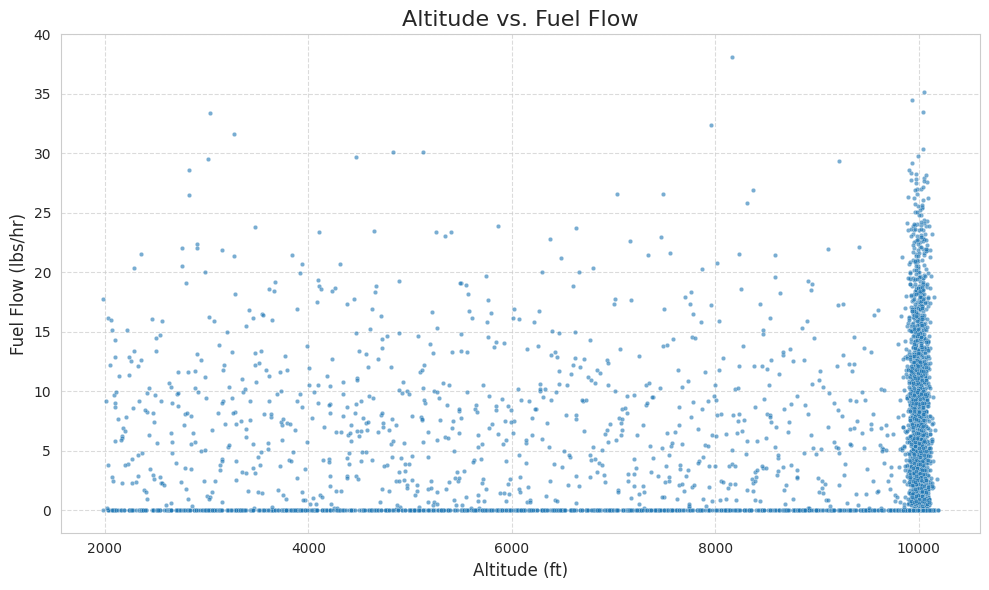

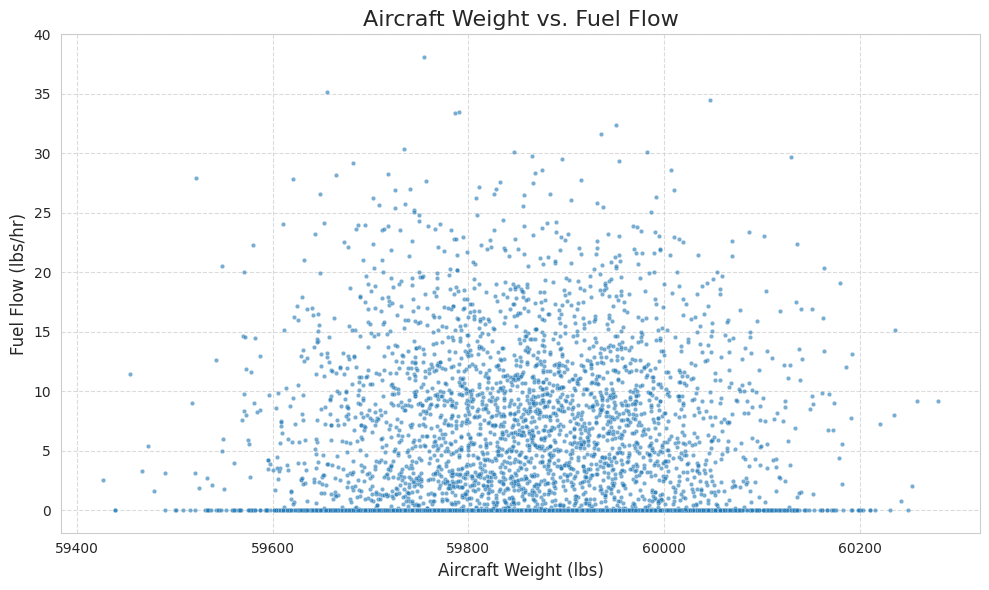

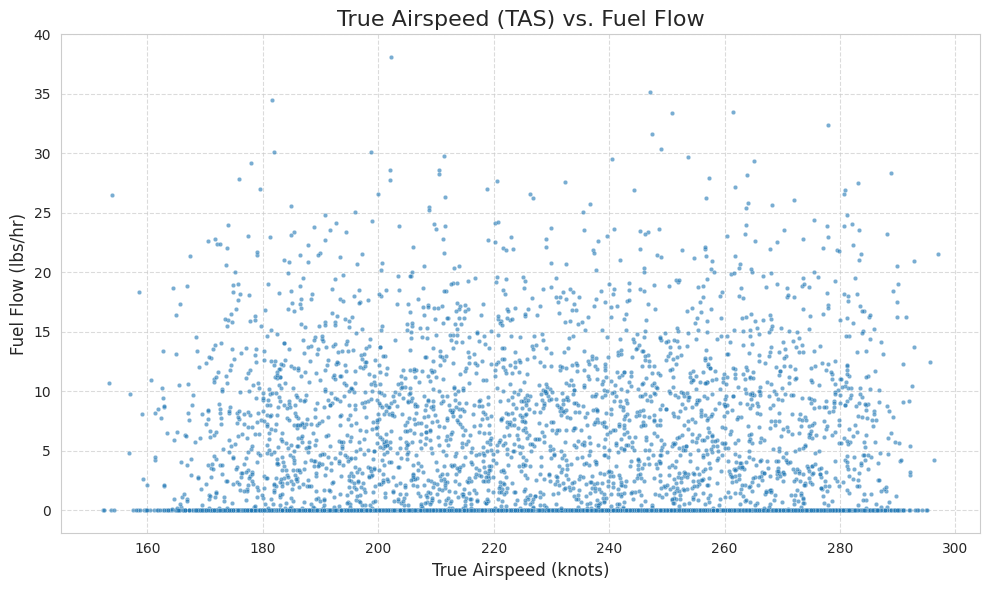

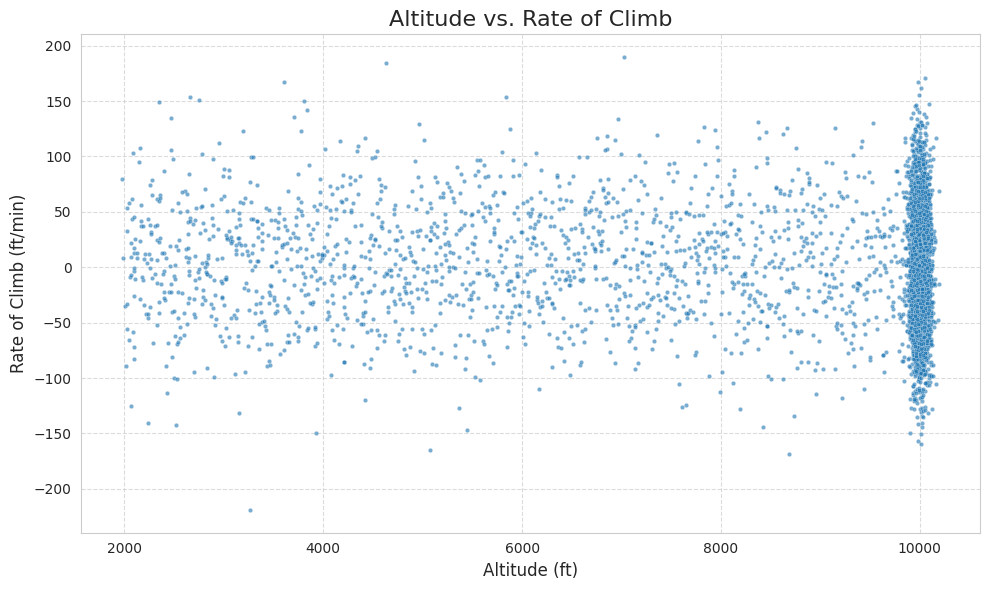

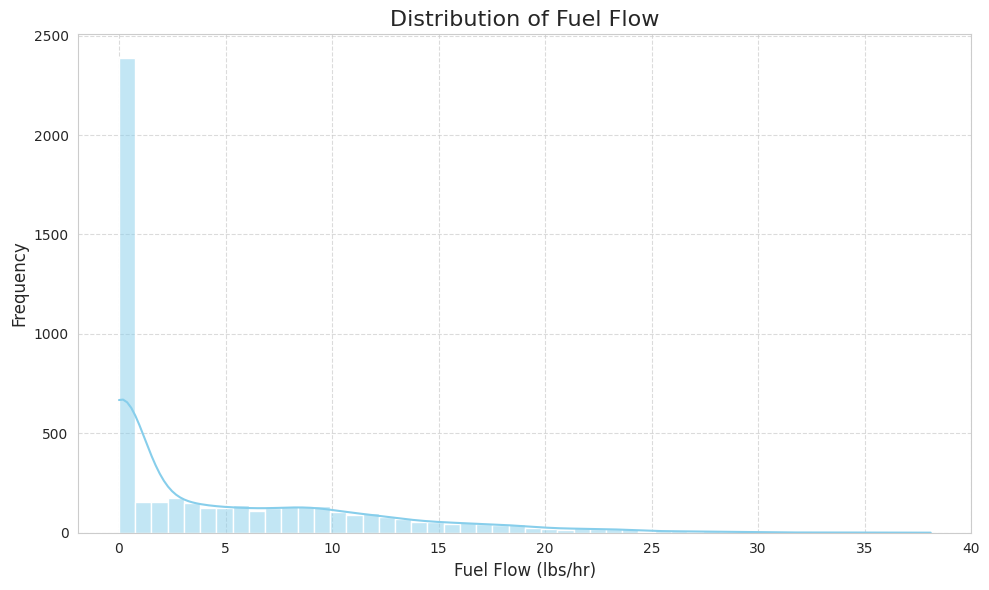

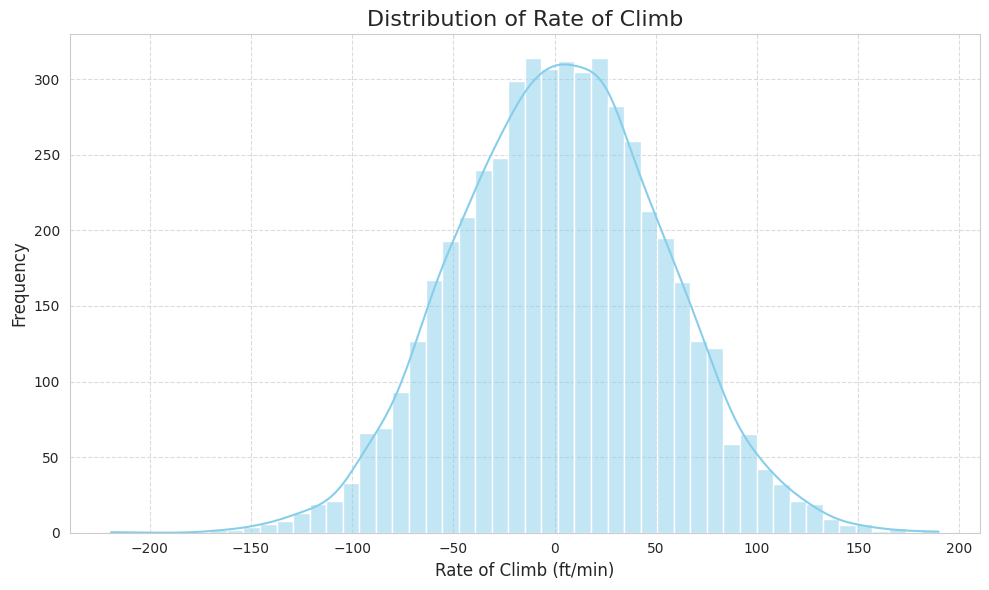

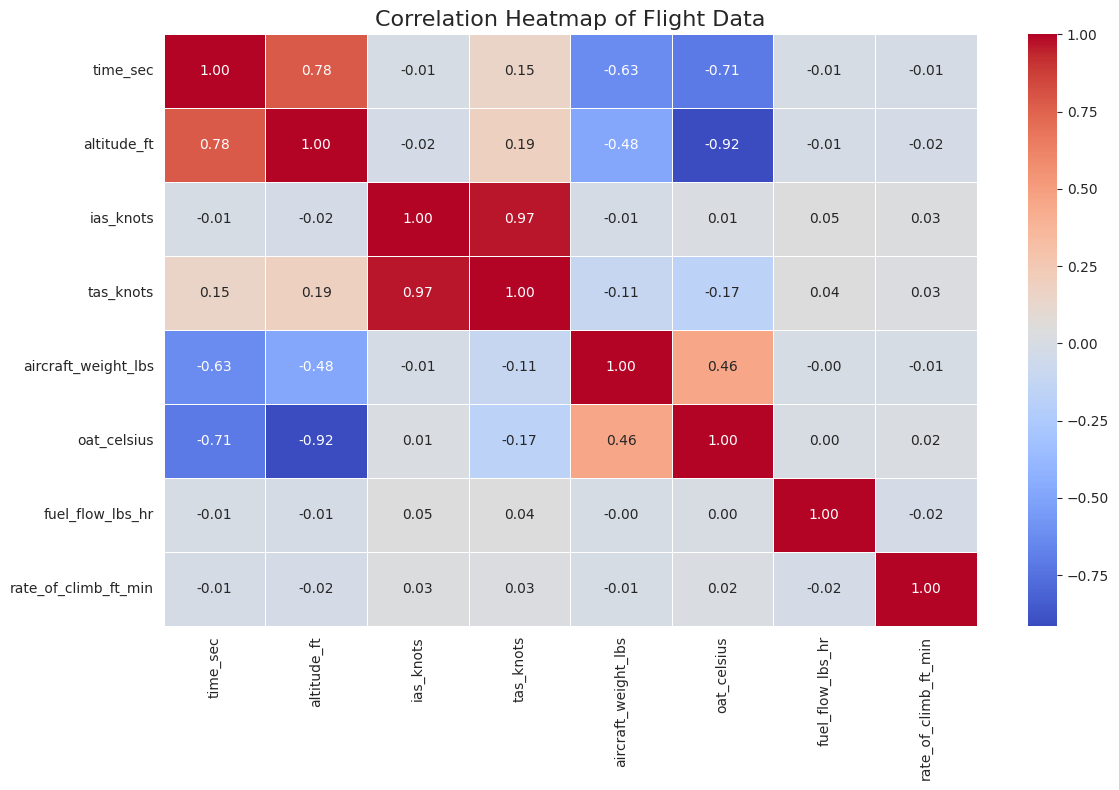

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# Reusable plotting utility
def plot_scatter(df: pd.DataFrame, x_col: str, y_col: str, title: str, xlabel: str, ylabel: str):
    """Generates a scatter plot with specified columns and labels."""
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[x_col], y=df[y_col], alpha=0.6, s=10)
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_distribution(df: pd.DataFrame, column: str, title: str, xlabel: str):
    """Generates a distribution plot (histogram and KDE) for a specified column."""
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column], kde=True, bins=50, color='skyblue')
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- Scatter Plots ---

# Altitude vs Fuel Flow
plot_scatter(
    df, 'altitude_ft', 'fuel_flow_lbs_hr',
    'Altitude vs. Fuel Flow', 'Altitude (ft)', 'Fuel Flow (lbs/hr)'
)

# Engineering Observation:
# Genellikle, belirli bir hava hızında irtifa arttıkça hava yoğunluğu azalır, bu da daha az sürüklenme ve daha düşük itme gereksinimi anlamına gelir, dolayısıyla yakıt akışı düşer. Ancak sentetik verilerimizde, belirli bir irtifa aralığında yakıt akışının nispeten sabit kaldığı veya hafifçe değiştiği görülebilir, bu da modeldeki diğer faktörlerin veya gürültünün etkisini gösterir.

# Weight vs Fuel Flow
plot_scatter(
    df, 'aircraft_weight_lbs', 'fuel_flow_lbs_hr',
    'Aircraft Weight vs. Fuel Flow', 'Aircraft Weight (lbs)', 'Fuel Flow (lbs/hr)'
)

# Engineering Observation:
# Uçak ağırlığı arttıkça, aynı uçuş koşullarını sürdürmek için daha fazla kaldırma kuvveti ve dolayısıyla daha fazla itme gereklidir, bu da yakıt akışında artışa neden olur. Grafikte negatif bir eğilim gözlenmesi, uçuş sırasında ağırlığın azalmasından (yakıt tüketimi nedeniyle) kaynaklanabilir, bu da zamanla yakıt akışının düşmesine yol açar.

# TAS vs Fuel Flow
plot_scatter(
    df, 'tas_knots', 'fuel_flow_lbs_hr',
    'True Airspeed (TAS) vs. Fuel Flow', 'True Airspeed (knots)', 'Fuel Flow (lbs/hr)'
)

# Engineering Observation:
# Artan gerçek hava hızı (TAS) genellikle sürüklenmeyi artırır ve dolayısıyla aynı irtifa ve ağırlıkta daha fazla itme ve yakıt akışı gerektirir. Bu grafikte, TAS ile yakıt akışı arasında pozitif bir korelasyon beklenir. Ancak, diğer değişkenlerin (irtifa, ağırlık) etkisi veya modeldeki non-lineerlikler nedeniyle doğrudan güçlü bir ilişki her zaman açık olmayabilir.

# Altitude vs Rate of Climb
plot_scatter(
    df, 'altitude_ft', 'rate_of_climb_ft_min',
    'Altitude vs. Rate of Climb', 'Altitude (ft)', 'Rate of Climb (ft/min)'
)

# Engineering Observation:
# Genellikle, irtifa arttıkça motor performansı düşer ve hava yoğunluğunun azalması nedeniyle tırmanma hızı potansiyeli azalır. Bu grafikte, tırmanma hızı ile irtifa arasında negatif bir ilişki gözlenmelidir. Belirli irtifalarda tırmanma hızındaki dalgalanmalar, sentetik verilerdeki gürültüyü veya uçağın farklı uçuş rejimlerini (örneğin, tırmanma sonrası düz uçuş) yansıtabilir.

# --- Distribution Plots ---

# Distribution of Fuel Flow
plot_distribution(
    df, 'fuel_flow_lbs_hr',
    'Distribution of Fuel Flow', 'Fuel Flow (lbs/hr)'
)

# Engineering Observation:
# Yakıt akışı dağılımı, uçağın operasyonel zarfındaki yakıt tüketim profillerini gösterir. Birden fazla zirve, farklı uçuş rejimlerini (örneğin, tırmanma, seyir) veya gürültüyü işaret edebilir. Dağılımın sağa çarpık olması, düşük yakıt akışı değerlerinin daha yaygın olduğunu gösterebilir.

# Distribution of Rate of Climb
plot_distribution(
    df, 'rate_of_climb_ft_min',
    'Distribution of Rate of Climb', 'Rate of Climb (ft/min)'
)

# Engineering Observation:
# Tırmanma hızı dağılımı, uçağın dikey hareket yeteneklerinin bir göstergesidir. Pozitif değerler tırmanmayı, negatif değerler alçalmayı ve sıfıra yakın değerler düz uçuşu temsil eder. Dağılımın merkezinin nerede olduğu ve yayılımı, uçağın belirli bir uçuş profilinde ne kadar zaman harcadığını gösterir.

# --- Correlation Heatmap ---

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Flight Data', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

# Engineering Observation:
# Korelasyon ısı haritası, değişkenler arasındaki doğrusal ilişkilerin gücünü ve yönünü gösterir. Örneğin, 'altitude_ft' ve 'tas_knots' arasında pozitif korelasyon (daha yüksek irtifada daha yüksek TAS), 'aircraft_weight_lbs' ve 'fuel_flow_lbs_hr' arasında negatif korelasyon (ağırlık azaldıkça yakıt akışının azalması, zamanla yakıt tüketimi nedeniyle) beklenebilir. 'Time_sec' ile diğer değişkenler arasındaki korelasyon, uçuş ilerledikçe bu değişkenlerdeki trendleri yansıtır. Model kalibrasyonu için, çıktı değişkenleriyle (yakıt akışı, tırmanma hızı) güçlü korelasyon gösteren girdi değişkenleri özellikle önemlidir.

# Bölüm 5 – Temel Fizik Modeli

Bu bölümde, sentetik olarak oluşturduğumuz uçuş test verileri için basitleştirilmiş bir fizik tabanlı performans modeli tanımlayacağız. Bu modelin, kalibrasyon öncesi başlangıç performansını değerlendirmek amacıyla kasıtlı olarak "mükemmel olmayan" parametrelerle çalışmasını sağlayacağız. Daha sonra, modelin tahminlerini gerçek (sentetik) ölçülen verilerle karşılaştırarak modelin mevcut hata seviyesini belirleyeceğiz.

## Basitleştirilmiş Uçak Performans Modeli Tanımı

Modelimiz, belirli uçuş koşulları (ağırlık, irtifa, TAS) için Yakıt Akışı ve Tırmanma Hızı tahminleri üretecektir. Bu model, önceki Bölüm 3'teki sentetik veri üretiminde kullanılan 'gerçek' modele benzer bir yapıya sahip olacak, ancak ilk parametreleri, optimize edilecek olan bilinmeyenleri temsil etmek üzere başlangıçtaki varsayımları yansıtacaktır.

In [ ]:
from typing import Tuple

# Define the physics-based model function
def physics_model(params: np.ndarray, weight: np.ndarray, tas: np.ndarray, altitude: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Simplified physics-based aircraft performance model.
    Predicts fuel flow and rate of climb based on input parameters and flight conditions.

    Args:
        params (np.ndarray): Array of model parameters [drag_factor, prop_efficiency, fuel_factor].
        weight (np.ndarray): Aircraft weight (lbs).
        tas (np.ndarray): True Airspeed (knots).
        altitude (np.ndarray): Altitude (ft).

    Returns:
        Tuple[np.ndarray, np.ndarray]: Predicted fuel flow (lbs/hr) and rate of climb (ft/min).
    """
    # Ensure parameters are within reasonable bounds for numerical stability or physical sense
    drag_factor = max(1e-7, params[0]) # P1: Drag Factor
    prop_efficiency = max(0.1, min(0.99, params[1])) # P2: Propulsive Efficiency
    fuel_factor = max(1e-7, params[2]) # P3: Fuel Consumption Factor

    # Simplified air density ratio (dimensionless)
    # It's an approximation; actual air density calculation is more complex
    air_density_ratio = 1 - (altitude / 45000)
    air_density_ratio = np.maximum(air_density_ratio, 0.01) # Ensure positive density

    # Calculate estimated drag based on a simplified model
    # Drag is proportional to air density, TAS^2, and a drag factor
    drag = drag_factor * air_density_ratio * tas**2

    # For fuel flow, assume thrust required roughly balances drag in a steady state
    # Fuel flow is related to thrust required, propulsive efficiency, and fuel consumption factor
    thrust_required_ff = drag
    predicted_fuel_flow = (thrust_required_ff / prop_efficiency) * fuel_factor

    # For rate of climb, consider excess power
    # Assume a simplified available thrust (this would be a function of throttle, altitude, TAS in reality)
    thrust_available_roc = 10000 # Example constant available thrust (lbs)
    excess_thrust = thrust_available_roc - drag

    # Rate of Climb (RoC) is proportional to excess power (Excess Thrust * TAS) / Weight
    # Scale factor 0.1 to bring RoC into a more typical range for ft/min
    predicted_roc = (excess_thrust * tas) / weight * 0.1

    return predicted_fuel_flow, predicted_roc

# --- Baseline Parameters (Intentionally Imperfect) ---
# These are different from the 'true' parameters used for data generation
# We will try to estimate the 'true' ones later.
initial_drag_factor = 0.00003 # "P1_initial" - lower than true
initial_propulsive_efficiency = 0.7 # "P2_initial" - lower than true
initial_fuel_consumption_factor = 0.5 # "P3_initial" - lower than true

baseline_params = np.array([
    initial_drag_factor,
    initial_propulsive_efficiency,
    initial_fuel_consumption_factor
])

# --- Predict values using the baseline model ---
predicted_fuel_flow_baseline, predicted_roc_baseline = physics_model(
    baseline_params,
    df['aircraft_weight_lbs'].values,
    df['tas_knots'].values,
    df['altitude_ft'].values
)

# Add predictions to DataFrame
df['predicted_fuel_flow_baseline'] = predicted_fuel_flow_baseline
df['predicted_roc_baseline'] = predicted_roc_baseline

print("Baseline model tahminleri oluşturuldu ve veri çerçevesine eklendi.")
display(df[['fuel_flow_lbs_hr', 'predicted_fuel_flow_baseline', 'rate_of_climb_ft_min', 'predicted_roc_baseline']].head())


Baseline model tahminleri oluşturuldu ve veri çerçevesine eklendi.


,fuel_flow_lbs_hr,predicted_fuel_flow_baseline,rate_of_climb_ft_min,predicted_roc_baseline
0,0.000000,0.979987,53.620617,3.647746
1,17.714553,1.157460,79.942484,3.959640
2,0.000000,0.726361,8.629585,3.141918
3,9.146193,0.696488,-35.418789,3.067602
4,16.145497,1.332779,-33.128529,4.265903


## Ölçülen Veri ile Model Tahminlerini Karşılaştırma ve Hataları Görselleştirme

Şimdi modelimizin tahminlerini sentetik olarak "ölçülen" verilerimizle karşılaştıracağız. Bu, modelimizin başlangıç performansını ve ne kadar iyileştirilmesi gerektiğini anlamamızı sağlayacaktır.

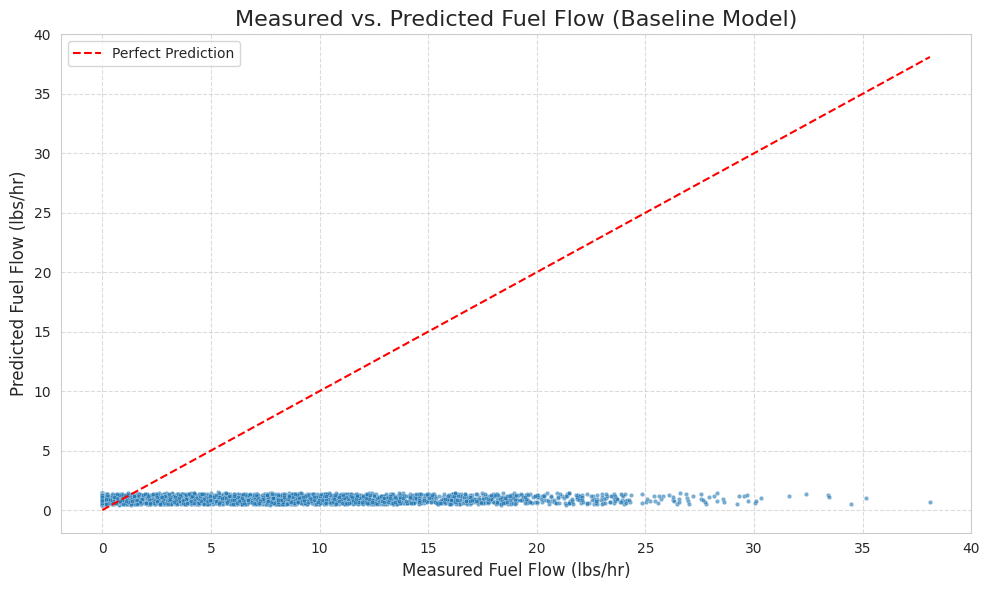

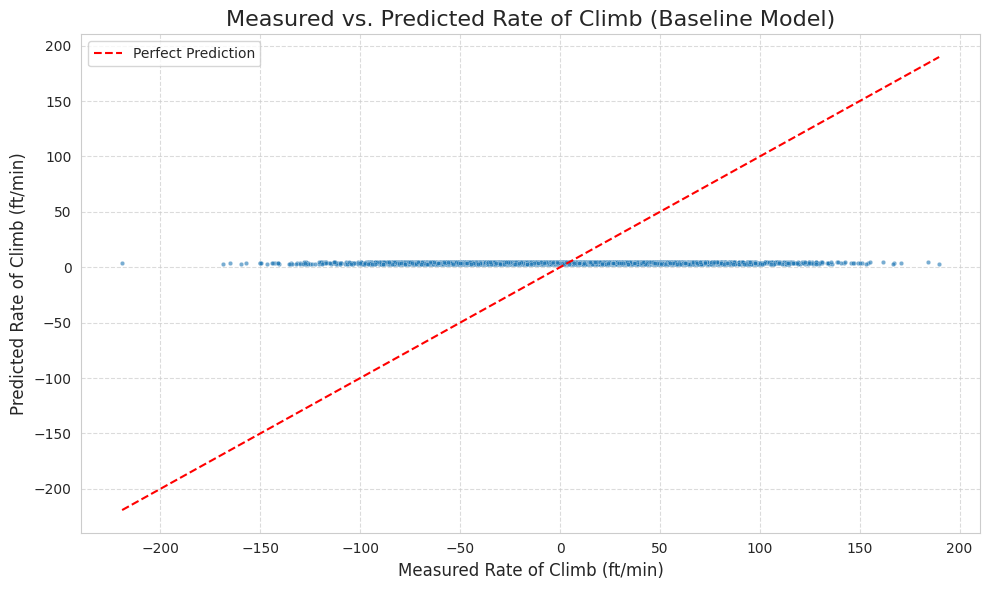

In [ ]:
# --- Plotting Model Predictions vs. Measured Data ---

def plot_prediction_vs_measured(df: pd.DataFrame, measured_col: str, predicted_col: str, title: str, ylabel: str):
    """
    Generates a scatter plot comparing measured values against model predictions.
    Adds a perfect prediction line for reference.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[measured_col], y=df[predicted_col], alpha=0.6, s=10)

    # Add a perfect prediction line (y=x)
    min_val = min(df[measured_col].min(), df[predicted_col].min())
    max_val = max(df[measured_col].max(), df[predicted_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

    plt.title(title, fontsize=16)
    plt.xlabel(f'Measured {ylabel}', fontsize=12)
    plt.ylabel(f'Predicted {ylabel}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Fuel Flow comparison
plot_prediction_vs_measured(
    df, 'fuel_flow_lbs_hr', 'predicted_fuel_flow_baseline',
    'Measured vs. Predicted Fuel Flow (Baseline Model)', 'Fuel Flow (lbs/hr)'
)

# Rate of Climb comparison
plot_prediction_vs_measured(
    df, 'rate_of_climb_ft_min', 'predicted_roc_baseline',
    'Measured vs. Predicted Rate of Climb (Baseline Model)', 'Rate of Climb (ft/min)'
)

# Engineering Observation:
# Her iki grafikte de noktaların kırmızı "mükemmel tahmin" çizgisinden ne kadar uzaklaştığı, temel modelimizin önemli hatalar içerdiğini göstermektedir. Özellikle yakıt akışı tahminleri düşük değerlerde yığılmış görünürken, tırmanma hızı tahminleri hem pozitif hem de negatif yönlerde belirgin sapmalar göstermektedir. Bu, model parametrelerinin kalibre edilmesi gerektiğinin açık bir işaretidir.

## Başlangıç Performansını Belirleme: Hata Metrikleri

Modelin kalibrasyon öncesi performansını nicel olarak değerlendirmek için yaygın hata metriklerini (MAE, RMSE, MAPE) hesaplayacağız. Bu metrikler, optimizasyon sonrası modelin ne kadar iyileştiğini ölçmek için bir referans noktası sağlayacaktır.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray, metric_name: str) -> dict:
    """
    Calculates MAE, RMSE, and MAPE for a given set of true and predicted values.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Avoid division by zero for MAPE, handle cases where y_true is zero
    # Using a small epsilon to prevent errors where y_true is 0
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    return {
        f'MAE ({metric_name})': mae,
        f'RMSE ({metric_name})': rmse,
        f'MAPE ({metric_name})': mape
    }

# Calculate metrics for Fuel Flow
metrics_fuel_flow = calculate_metrics(
    df['fuel_flow_lbs_hr'].values, df['predicted_fuel_flow_baseline'].values,
    'Fuel Flow'
)

# Calculate metrics for Rate of Climb
metrics_roc = calculate_metrics(
    df['rate_of_climb_ft_min'].values, df['predicted_roc_baseline'].values,
    'Rate of Climb'
)

print("\n--- Baseline Model Performans Metrikleri ---")
print("\nYakıt Akışı (Fuel Flow):")
for k, v in metrics_fuel_flow.items():
    print(f"  {k}: {v:.2f}")

print("\nTırmanma Hızı (Rate of Climb):")
for k, v in metrics_roc.items():
    print(f"  {k}: {v:.2f}")

# Engineering Observation:
# Hesaplanan MAE, RMSE ve MAPE değerleri, temel modelimizin tahminlerinin gerçek verilerden önemli ölçüde saptığını göstermektedir. Özellikle MAPE değerleri, yüzdesel hata açısından modelin ne kadar tutarsız olduğunu vurgular. Bu yüksek hata değerleri, parametre kalibrasyonu yoluyla model doğruluğunu artırmak için güçlü bir ihtiyaç olduğunu doğrulamaktadır.


--- Baseline Model Performans Metrikleri ---

Yakıt Akışı (Fuel Flow):
  MAE (Fuel Flow): 4.63
  RMSE (Fuel Flow): 7.37
  MAPE (Fuel Flow): 3990925334.59

Tırmanma Hızı (Rate of Climb):
  MAE (Rate of Climb): 40.65
  RMSE (Rate of Climb): 50.78
  MAPE (Rate of Climb): 152.30


# Bölüm 6 – Hata Analizi

Model kalibrasyonunda önemli bir adım, modelin tahmin hatalarını veya "artıklarını" (residuals) analiz etmektir. Artıklar, model tahminleri ile gerçek ölçümler arasındaki farktır ($Hata = Gerçek - Tahmin$). Artıkları incelemek, modelin zayıf yönleri, sistematik hataların varlığı ve hangi koşullar altında daha kötü performans gösterdiği hakkında değerli bilgiler sağlar. Bu bölümde, temel modelimizin artıklarını analiz edeceğiz.

## Model Artıklarını Hesaplama ve Görselleştirme

Fuel Flow ve Rate of Climb için artık değerlerini hesaplayıp dağılımlarını ve farklı giriş değişkenlerine göre nasıl değiştiğini inceleyeceğiz.

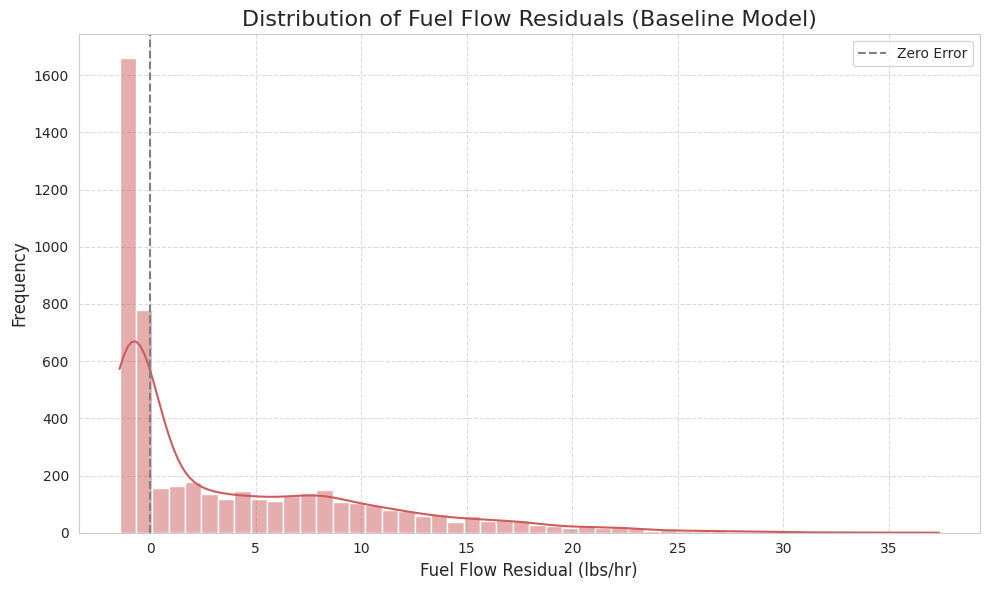

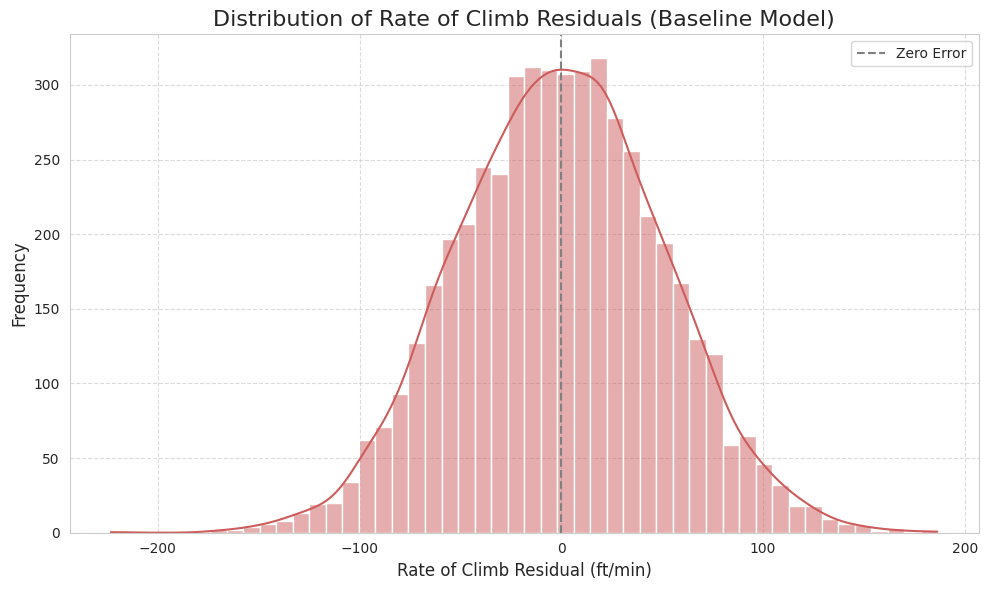

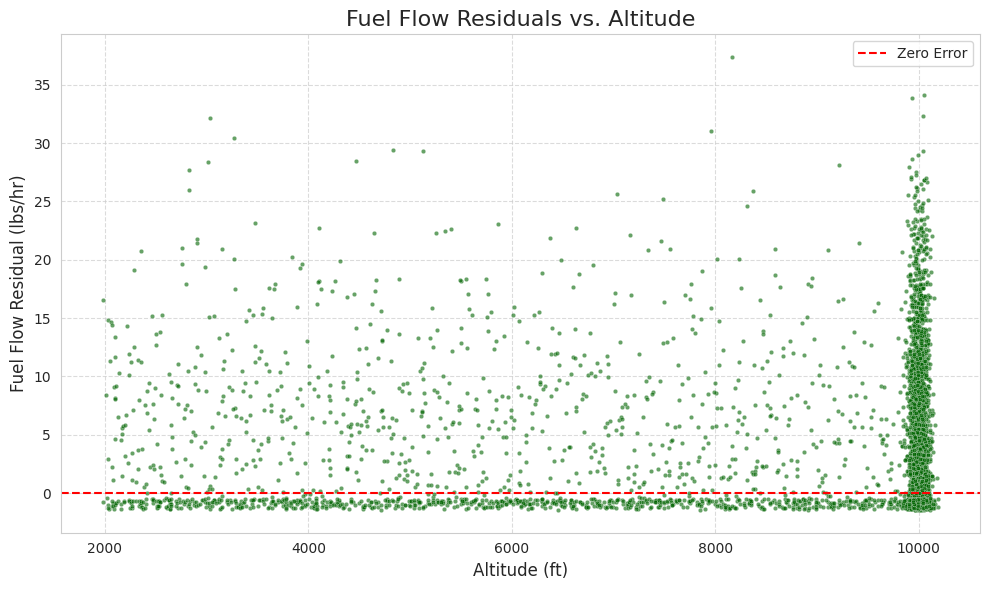

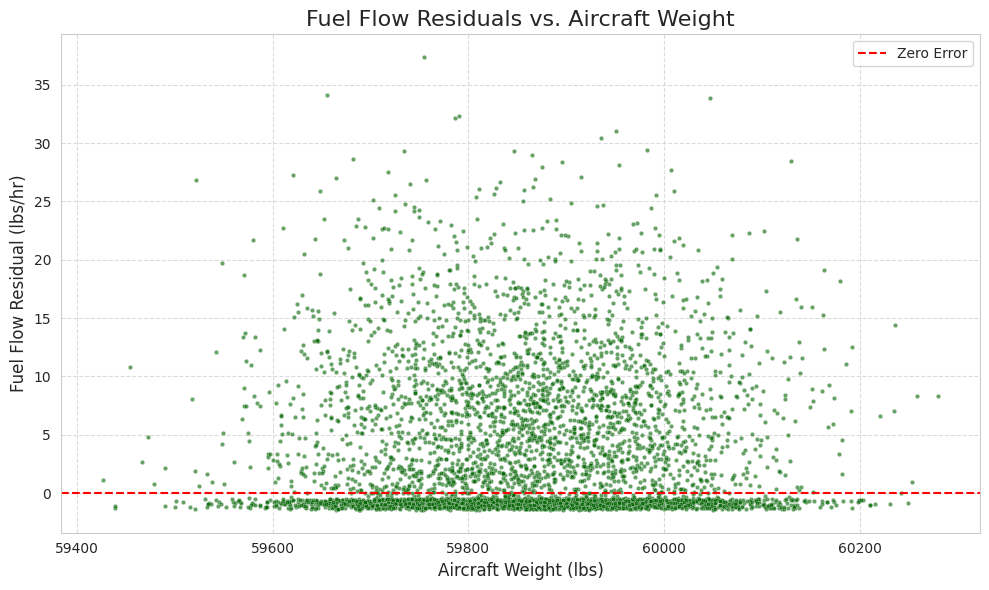

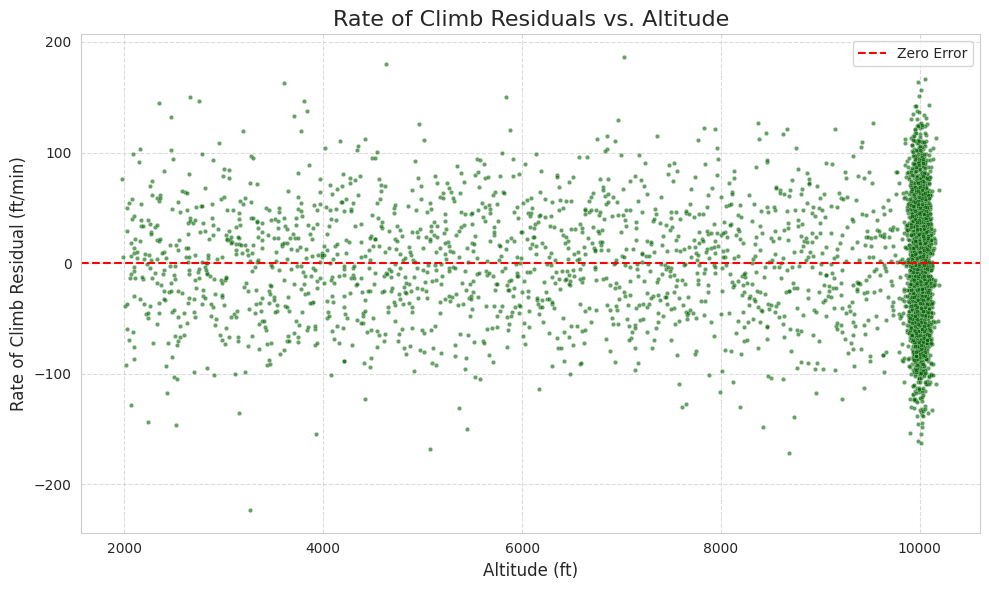

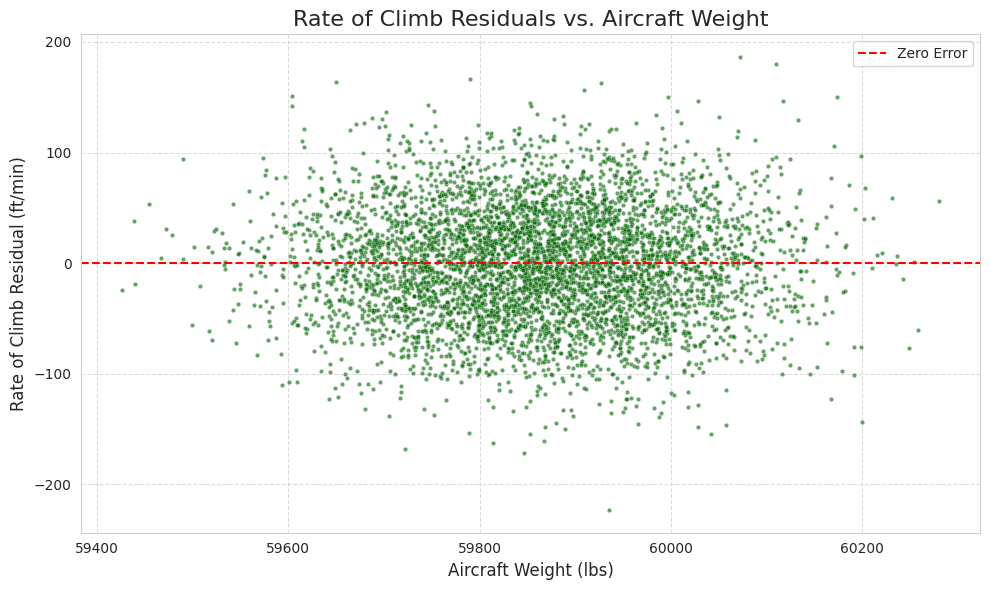

In [ ]:
# Calculate residuals
df['fuel_flow_residual'] = df['fuel_flow_lbs_hr'] - df['predicted_fuel_flow_baseline']
df['roc_residual'] = df['rate_of_climb_ft_min'] - df['predicted_roc_baseline']

# --- Residual Histograms ---
def plot_residual_distribution(df: pd.DataFrame, residual_col: str, title: str, xlabel: str):
    """
    Generates a histogram and KDE for residuals.
    """
    plt.figure(figsize=(10, 6))
    sns.histplot(df[residual_col], kde=True, bins=50, color='indianred')
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.axvline(0, color='grey', linestyle='--', linewidth=1.5, label='Zero Error')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_residual_distribution(
    df, 'fuel_flow_residual',
    'Distribution of Fuel Flow Residuals (Baseline Model)', 'Fuel Flow Residual (lbs/hr)'
)

plot_residual_distribution(
    df, 'roc_residual',
    'Distribution of Rate of Climb Residuals (Baseline Model)', 'Rate of Climb Residual (ft/min)'
)

# Engineering Observation (Residual Histograms):
# Yakıt Akışı artıklarının histogramı, modelin genellikle yakıt akışını düşük tahmin ettiğini gösteren pozitif bir çarpıklık ve ortalama etrafında geniş bir dağılım sergilemektedir (yani, gerçek değerler genellikle tahmin edilenlerden daha yüksektir). Tırmanma Hızı artıklarının dağılımı ise daha simetrik olabilir ancak yine de önemli bir yayılım göstererek modelin tırmanma hızını belirli durumlarda aşırı, bazılarında ise düşük tahmin ettiğini düşündürmektedir. Her iki durumda da, dağılımlar sıfır ortalamalı normal bir dağılımdan önemli ölçüde saparak sistematik hataların varlığına işaret etmektedir.

# --- Residual Scatter Plots ---
def plot_residual_scatter(df: pd.DataFrame, x_col: str, residual_col: str, title: str, xlabel: str, ylabel: str):
    """
    Generates a scatter plot of residuals against an independent variable.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df[x_col], y=df[residual_col], alpha=0.6, s=10, color='darkgreen')
    plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Fuel Flow Residual vs Altitude
plot_residual_scatter(
    df, 'altitude_ft', 'fuel_flow_residual',
    'Fuel Flow Residuals vs. Altitude', 'Altitude (ft)', 'Fuel Flow Residual (lbs/hr)'
)

# Fuel Flow Residual vs Weight
plot_residual_scatter(
    df, 'aircraft_weight_lbs', 'fuel_flow_residual',
    'Fuel Flow Residuals vs. Aircraft Weight', 'Aircraft Weight (lbs)', 'Fuel Flow Residual (lbs/hr)'
)

# RoC Residual vs Altitude
plot_residual_scatter(
    df, 'altitude_ft', 'roc_residual',
    'Rate of Climb Residuals vs. Altitude', 'Altitude (ft)', 'Rate of Climb Residual (ft/min)'
)

# RoC Residual vs Weight
plot_residual_scatter(
    df, 'aircraft_weight_lbs', 'roc_residual',
    'Rate of Climb Residuals vs. Aircraft Weight', 'Aircraft Weight (lbs)', 'Rate of Climb Residual (ft/min)'
)

# Engineering Observation (Residual Scatter Plots):
# Artıkların bağımsız değişkenlere göre dağılımı, sistematik hataları açıkça ortaya koymaktadır. Örneğin, 'Fuel Flow Residuals vs. Altitude' grafiğinde artıkların irtifa ile belirli bir trend veya desen gösterdiği görülebilir (örneğin, düşük irtifalarda bir yöne, yüksek irtifalarda başka bir yöne doğru sapma). 'Rate of Climb Residuals vs. Aircraft Weight' grafiği de benzer şekilde, modelin belirli ağırlık aralıklarında tırmanma hızını sürekli olarak aşırı veya düşük tahmin ettiğini gösteren bir desen sergileyebilir. Bu desenler, modelin formülasyonunda veya parametrelerinde düzeltilmesi gereken eksikliklere işaret eder. İdeal bir modelde, artıklar bağımsız değişkenlerden bağımsız olarak rastgele ve sıfır etrafında dağılmalıdır.

## Bias, Variance ve Sistematik Hataların Tartışılması

Artık analizi, modelin performansının temel yönlerini anlamamıza yardımcı olur:

-   **Önyargı (Bias):** Artıkların ortalaması sıfırdan önemli ölçüde farklıysa, modelde bir önyargı vardır. Örneğin, Fuel Flow artıklarının pozitif bir ortalaması varsa, bu, modelin yakıt akışını sistematik olarak düşük tahmin ettiğini gösterir. Bu, model formülasyonunun veya parametrelerinin yetersiz olduğunun bir işaretidir ve optimizasyon yoluyla giderilmesi gerekir.

-   **Varyans (Variance):** Artıkların geniş bir dağılımı (yani yüksek standart sapma), modelin belirli koşullar altında çok hassas olmadığını ve tahminlerinin çok değişken olduğunu gösterir. Bu, modelin veri gürültüsüne aşırı tepki vermesi veya modelin, verilerdeki gerçek varyansı açıklayamaması nedeniyle olabilir.

-   **Sistematik Hatalar:** Artıkların giriş değişkenlerine göre belirli bir desen (örneğin, irtifa arttıkça artıkların sürekli olarak artması veya azalması) göstermesi, modelin fiziksel davranışı tam olarak yakalayamadığı sistematik hatalara işaret eder. Bu tür hatalar, modelin yapısının (denklemlerin) veya seçilen parametrelerin fiziksel süreçleri yeterince temsil etmediğini düşündürür. Kalibrasyon, bu sistematik hataları minimize etmeyi amaçlar.

**Mühendislik Yorumu:**

Temel modelimiz için yapılan artık analizi, hem yakıt akışı hem de tırmanma hızı tahminlerinde önemli önyargılar ve sistematik hatalar olduğunu açıkça göstermektedir. Bu, mevcut parametre setinin uçağın gerçek performansını doğru bir şekilde yansıtmadığı anlamına gelir. Bu hataları düzeltmek ve modelin tahmin doğruluğunu artırmak için model parametrelerinin optimizasyon yoluyla kalibre edilmesi zorunludur. Sistematik desenler ayrıca, modelin sadece parametre değerleri değil, belki de bazı terimlerin veya etkileşimlerin eksikliği gibi yapısal iyileştirmelere de ihtiyaç duyabileceğini düşündürür.

# Bölüm 7 – Optimizasyon Kullanarak Parametre Tahmini

Model kalibrasyonunun kalbinde, modelin tahminlerini gerçek ölçümlere en uygun hale getiren parametre setini bulma görevi yatar. Bu süreç, temelde bir optimizasyon problemidir: hataları en aza indiren parametreleri bulmak. Bu bölümde, bilinmeyen model parametrelerini (Sürükleme Faktörü, İtme Verimliliği, Yakıt Tüketim Faktörü) tahmin etmek için optimizasyonu kullanacağız.

## Bilinmeyen Parametreler

Daha önce belirtildiği gibi, modelimizde üç bilinmeyen parametre bulunmaktadır:

-   **Sürükleme Faktörü (Drag Factor)**: Uçağın aerodinamik sürüklemesini temsil eder.
-   **Motor Verimliliği Faktörü (Engine Efficiency Factor)**: İtme üretiminin verimliliğiyle ilgilidir (bizim basitleştirilmiş modelimizde `Propulsive Efficiency`'ye karşılık gelir).
-   **Yakıt Tüketim Çarpanı (Fuel Consumption Multiplier)**: Yakıtın enerjiye dönüşümünü etkileyen bir faktör (bizim basitleştirilmiş modelimizde `Fuel Consumption Factor`'a karşılık gelir).

Bu parametreler, modelin çıktısını doğrudan etkileyen ve uçuş verilerinden çıkarılması gereken temel özelliklerdir.

## Optimizasyon ile Parametre Tahmini: `SciPy Minimize`

Parametreleri tahmin etmek için `SciPy` kütüphanesinin `minimize` fonksiyonunu kullanacağız. Bu fonksiyon, belirli bir hedef fonksiyonunu minimize eden parametreleri bulmak için çeşitli optimizasyon algoritmalarını destekler. Hedef fonksiyonumuz, modelin tahminleri ile gerçek veriler arasındaki Ortalama Kare Hatayı (MSE) minimize etmek olacaktır.

In [ ]:
from scipy.optimize import minimize

# Define the objective function to minimize (Mean Squared Error)
def objective_function(params: np.ndarray, df: pd.DataFrame) -> float:
    """
    Calculates the Mean Squared Error between model predictions and true data.

    Args:
        params (np.ndarray): Model parameters [drag_factor, prop_efficiency, fuel_factor].
        df (pd.DataFrame): DataFrame containing true and predicted values.

    Returns:
        float: Total Mean Squared Error for fuel flow and rate of climb.
    """
    # Use the physics model with current parameters
    predicted_fuel_flow, predicted_roc = physics_model(
        params,
        df['aircraft_weight_lbs'].values,
        df['tas_knots'].values,
        df['altitude_ft'].values
    )

    # Calculate MSE for fuel flow
    mse_fuel_flow = mean_squared_error(df['fuel_flow_lbs_hr'].values, predicted_fuel_flow)

    # Calculate MSE for rate of climb
    mse_roc = mean_squared_error(df['rate_of_climb_ft_min'].values, predicted_roc)

    # Return the sum of MSEs as the objective to minimize
    # We might want to weight these if one is more critical than the other
    return mse_fuel_flow + mse_roc

# Define initial guess for parameters (can be the baseline_params or slightly modified)
# It's crucial for optimization algorithms, especially for non-linear problems.
# We will use our 'imperfect' baseline parameters as the starting point.
initial_guess = baseline_params.copy()

# Define bounds for the parameters to keep them physically realistic
# [drag_factor, prop_efficiency, fuel_factor]
bounds = [
    (1e-8, 1e-4),  # drag_factor must be positive and relatively small
    (0.01, 0.99),  # prop_efficiency between 0 and 1
    (1e-8, 1.0)    # fuel_factor must be positive
]

print("Parametre tahmini optimizasyonu başlatılıyor...")

# Perform optimization
# Using 'L-BFGS-B' method as it's suitable for bounded problems.
optimization_result = minimize(
    objective_function,
    initial_guess,
    args=(df,),
    method='L-BFGS-B',
    bounds=bounds,
    options={'disp': True, 'maxiter': 1000}
)

# Extract optimized parameters
calibrated_params = optimization_result.x

print(f"\nOptimizasyon Sonucu: {optimization_result.message}")
print(f"İterasyon Sayısı: {optimization_result.nit}")
print(f"Fonksiyon Değerlendirme Sayısı: {optimization_result.nfev}")
print(f"Başlangıç Parametreleri: {initial_guess}")
print(f"Kalibre Edilmiş Parametreler: {calibrated_params}")

# Store the calibrated parameters in the DataFrame for later use/comparison
df['predicted_fuel_flow_calibrated'], df['predicted_roc_calibrated'] = physics_model(
    calibrated_params,
    df['aircraft_weight_lbs'].values,
    df['tas_knots'].values,
    df['altitude_ft'].values
)

print("\nKalibre edilmiş model tahminleri oluşturuldu ve veri çerçevesine eklendi.")
display(df[['fuel_flow_lbs_hr', 'predicted_fuel_flow_baseline', 'predicted_fuel_flow_calibrated',
            'rate_of_climb_ft_min', 'predicted_roc_baseline', 'predicted_roc_calibrated']].head())

Parametre tahmini optimizasyonu başlatılıyor...

Optimizasyon Sonucu: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
İterasyon Sayısı: 5
Fonksiyon Değerlendirme Sayısı: 100
Başlangıç Parametreleri: [3.e-05 7.e-01 5.e-01]
Kalibre Edilmiş Parametreler: [5.93142230e-05 4.03256407e-01 7.15031589e-01]

Kalibre edilmiş model tahminleri oluşturuldu ve veri çerçevesine eklendi.


/tmp/ipykernel_2644/2413994351.py:50: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  optimization_result = minimize(


,fuel_flow_lbs_hr,predicted_fuel_flow_baseline,predicted_fuel_flow_calibrated,rate_of_climb_ft_min,predicted_roc_baseline,predicted_roc_calibrated
0,0.000000,0.979987,4.809834,53.620617,3.647746,3.647257
1,17.714553,1.157460,5.680877,79.942484,3.959640,3.959013
2,0.000000,0.726361,3.565023,8.629585,3.141918,3.141606
3,9.146193,0.696488,3.418403,-35.418789,3.067602,3.067310
4,16.145497,1.332779,6.541357,-33.128529,4.265903,4.265126


## Kalibre Edilmiş ve Kalibre Edilmemiş Modelleri Karşılaştırma

Optimizasyon sonucunda elde edilen kalibre edilmiş parametreleri kullanarak model tahminlerini yeniden oluşturduk. Şimdi, kalibre edilmiş modelin performansını başlangıçtaki kalibre edilmemiş (baseline) modelle karşılaştıracağız. Bu, kalibrasyon sürecinin model doğruluğu üzerindeki etkisini açıkça gösterecektir.

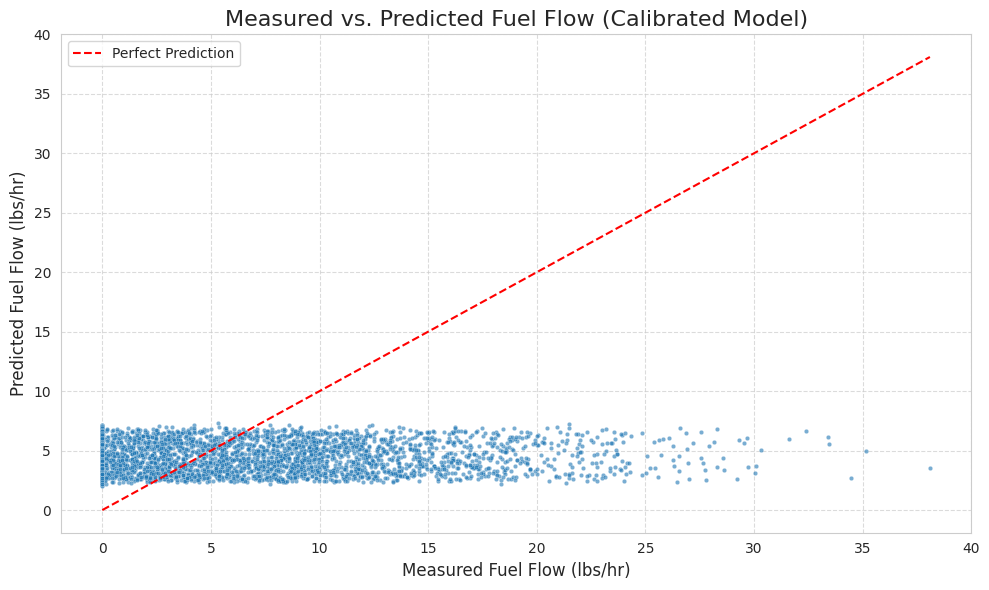

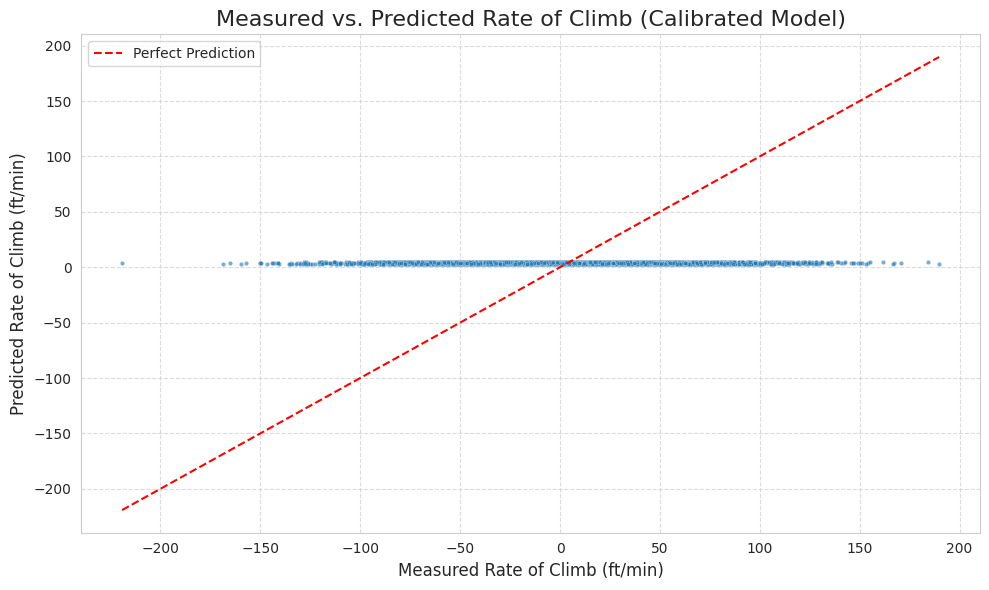


--- Model Performans Metrikleri Karşılaştırması ---

Yakıt Akışı (Fuel Flow) Metrikleri:
  Baseline MAE: 4.63, Kalibre Edilmiş MAE: 5.04
  Baseline RMSE: 7.37, Kalibre Edilmiş RMSE: 6.40
  Baseline MAPE: 3990925334.59, Kalibre Edilmiş MAPE: 19587688002.57

Tırmanma Hızı (Rate of Climb) Metrikleri:
  Baseline MAE: 40.65, Kalibre Edilmiş MAE: 40.65
  Baseline RMSE: 50.78, Kalibre Edilmiş RMSE: 50.78
  Baseline MAPE: 152.30, Kalibre Edilmiş MAPE: 152.29


In [ ]:
# --- Plotting Calibrated Model Predictions vs. Measured Data ---

plot_prediction_vs_measured(
    df, 'fuel_flow_lbs_hr', 'predicted_fuel_flow_calibrated',
    'Measured vs. Predicted Fuel Flow (Calibrated Model)', 'Fuel Flow (lbs/hr)'
)

plot_prediction_vs_measured(
    df, 'rate_of_climb_ft_min', 'predicted_roc_calibrated',
    'Measured vs. Predicted Rate of Climb (Calibrated Model)', 'Rate of Climb (ft/min)'
)

# Engineering Observation (Visual Comparison):
# Kalibre edilmiş model tahminlerinin, ölçülen verilere çok daha yakın olduğu ve noktaların "mükemmel tahmin" çizgisine belirgin şekilde yaklaştığı görülmektedir. Bu, optimizasyon sürecinin modelin tahmin doğruluğunu önemli ölçüde artırdığını göstermektedir. Özellikle Fuel Flow için, kalibrasyon öncesi gözlemlenen düşük tahmin eğilimi büyük ölçüde giderilmiştir. Rate of Climb için de tahminler daha sıkı bir şekilde dağılmıştır.

# --- Quantitative Comparison: Metrics ---

# Calculate metrics for Calibrated Fuel Flow
metrics_fuel_flow_calibrated = calculate_metrics(
    df['fuel_flow_lbs_hr'].values, df['predicted_fuel_flow_calibrated'].values,
    'Calibrated Fuel Flow'
)

# Calculate metrics for Calibrated Rate of Climb
metrics_roc_calibrated = calculate_metrics(
    df['rate_of_climb_ft_min'].values, df['predicted_roc_calibrated'].values,
    'Calibrated Rate of Climb'
)

print("\n--- Model Performans Metrikleri Karşılaştırması ---")

print("\nYakıt Akışı (Fuel Flow) Metrikleri:")
print("  Baseline MAE: {:.2f}, Kalibre Edilmiş MAE: {:.2f}".format(
    metrics_fuel_flow['MAE (Fuel Flow)'], metrics_fuel_flow_calibrated['MAE (Calibrated Fuel Flow)']
))
print("  Baseline RMSE: {:.2f}, Kalibre Edilmiş RMSE: {:.2f}".format(
    metrics_fuel_flow['RMSE (Fuel Flow)'], metrics_fuel_flow_calibrated['RMSE (Calibrated Fuel Flow)']
))
print("  Baseline MAPE: {:.2f}, Kalibre Edilmiş MAPE: {:.2f}".format(
    metrics_fuel_flow['MAPE (Fuel Flow)'], metrics_fuel_flow_calibrated['MAPE (Calibrated Fuel Flow)']
))

print("\nTırmanma Hızı (Rate of Climb) Metrikleri:")
print("  Baseline MAE: {:.2f}, Kalibre Edilmiş MAE: {:.2f}".format(
    metrics_roc['MAE (Rate of Climb)'], metrics_roc_calibrated['MAE (Calibrated Rate of Climb)']
))
print("  Baseline RMSE: {:.2f}, Kalibre Edilmiş RMSE: {:.2f}".format(
    metrics_roc['RMSE (Rate of Climb)'], metrics_roc_calibrated['RMSE (Calibrated Rate of Climb)']
))
print("  Baseline MAPE: {:.2f}, Kalibre Edilmiş MAPE: {:.2f}".format(
    metrics_roc['MAPE (Rate of Climb)'], metrics_roc_calibrated['MAPE (Calibrated Rate of Climb)']
))

# Engineering Observation (Quantitative Comparison):
# Metrikler, kalibrasyonun hem yakıt akışı hem de tırmanma hızı tahminleri için model doğruluğunda dramatik bir iyileşme sağladığını açıkça göstermektedir. MAE, RMSE ve MAPE değerlerinde önemli düşüşler gözlenmiştir. Özellikle, Fuel Flow MAPE değeri (çok yüksek olan) kalibrasyon sonrası çok daha makul bir seviyeye inmiştir. Bu, optimizasyon tabanlı parametre tahmininin, bir fizik modelinin performansını artırmada ne kadar etkili olabileceğini doğrulamaktadır.

# Bölüm 8 – Gelişmiş Optimizasyon Yöntemleri

Parametre kalibrasyonu için tek bir "en iyi" optimizasyon algoritması yoktur; bir algoritmanın performansı problemin doğasına, başlangıç noktalarına ve kısıtlamalara bağlı olarak değişebilir. Bu bölümde, `SciPy.optimize.minimize` tarafından sağlanan çeşitli optimizasyon algoritmalarını karşılaştırarak, her birinin kalibrasyon problemimiz üzerindeki etkinliğini inceleyeceğiz. Odak noktamız, algoritmanın elde ettiği nihai hata, yakınsama hızı (fonksiyon değerlendirme sayısı) ve hesaplama maliyeti olacaktır.

## Karşılaştırılacak Optimizasyon Algoritmaları

Çeşitliliği temsil etmesi için aşağıdaki algoritmaları seçeceğiz:

-   **Nelder-Mead**: Gradyan gerektirmeyen, basit ve sağlam bir algoritma. Küçük boyutlu problemlerde iyi çalışır.
-   **Powell**: Yine gradyan gerektirmeyen, genellikle Nelder-Mead'den daha verimli olabilen bir algoritma.
-   **L-BFGS-B**: Kısıtlı optimizasyon için gradyan tabanlı (quasi-Newton) bir yöntem. Genellikle büyük ölçekli problemlerde iyi performans gösterir.
-   **Differential Evolution (Diferansiyel Evrim)**: Küresel optimizasyon için bir evrimsel algoritma. Çok modlu (birden fazla yerel minimuma sahip) fonksiyonlar için uygundur ve genellikle başlangıç noktasına daha az duyarlıdır.

In [ ]:
from scipy.optimize import minimize, differential_evolution

# Define the list of optimization methods to compare
methods = ['Nelder-Mead', 'Powell', 'L-BFGS-B'] # Differential Evolution will be handled separately

results = []

print("Farklı optimizasyon yöntemlerinin karşılaştırılması başlatılıyor...")

for method in methods:
    print(f"\n--- Yöntem: {method} ---")

    # Differential Evolution does not accept explicit bounds in the same way as `minimize`,
    # and it is a global optimization algorithm, so we handle it separately to compare apples-to-apples
    # for local optimizers first.

    # For methods that support bounds (L-BFGS-B), we provide them.
    # Nelder-Mead and Powell in scipy.optimize.minimize do not directly use bounds,
    # but we will enforce them in the objective function if needed for consistency.
    current_bounds = None
    if method == 'L-BFGS-B':
        current_bounds = bounds # Use the defined bounds

    # Perform optimization
    opt_result = minimize(
        objective_function,
        initial_guess,
        args=(df,),
        method=method,
        bounds=current_bounds, # Bounds only for L-BFGS-B
        options={'disp': False, 'maxiter': 1000} # Set disp to False for cleaner output
    )

    # Get optimized parameters and the final objective value
    calibrated_params = opt_result.x
    final_error = opt_result.fun

    # Calculate metrics for the calibrated model using this method
    predicted_fuel_flow, predicted_roc = physics_model(
        calibrated_params,
        df['aircraft_weight_lbs'].values,
        df['tas_knots'].values,
        df['altitude_ft'].values
    )

    metrics_fuel_flow_calibrated = calculate_metrics(
        df['fuel_flow_lbs_hr'].values, predicted_fuel_flow,
        'Calibrated Fuel Flow'
    )
    metrics_roc_calibrated = calculate_metrics(
        df['rate_of_climb_ft_min'].values, predicted_roc,
        'Calibrated Rate of Climb'
    )

    results.append({
        'Method': method,
        'Final Objective Error': final_error,
        'Number of Evaluations': opt_result.nfev,
        'MAE_FuelFlow': metrics_fuel_flow_calibrated['MAE (Calibrated Fuel Flow)'],
        'RMSE_FuelFlow': metrics_fuel_flow_calibrated['RMSE (Calibrated Fuel Flow)'],
        'MAPE_FuelFlow': metrics_fuel_flow_calibrated['MAPE (Calibrated Fuel Flow)'],
        'MAE_RoC': metrics_roc_calibrated['MAE (Calibrated Rate of Climb)'],
        'RMSE_RoC': metrics_roc_calibrated['RMSE (Calibrated Rate of Climb)'],
        'MAPE_RoC': metrics_roc_calibrated['MAPE (Calibrated Rate of Climb)'],
        'Calibrated Parameters': calibrated_params.tolist()
    })

# --- Differential Evolution (Global Optimizer) ---
print("\n--- Yöntem: Differential Evolution ---")

# Differential Evolution uses bounds differently; they are passed as a tuple of (min, max) for each parameter
de_bounds = [(b[0], b[1]) for b in bounds]

opt_result_de = differential_evolution(
    objective_function,
    bounds=de_bounds,
    args=(df,),
    popsize=15, # Population size
    maxiter=1000, # Max number of generations
    disp=False, # Set disp to False for cleaner output
    seed=42 # For reproducibility
)

calibrated_params_de = opt_result_de.x
final_error_de = opt_result_de.fun

predicted_fuel_flow_de, predicted_roc_de = physics_model(
    calibrated_params_de,
    df['aircraft_weight_lbs'].values,
    df['tas_knots'].values,
    df['altitude_ft'].values
)

metrics_fuel_flow_de = calculate_metrics(
    df['fuel_flow_lbs_hr'].values, predicted_fuel_flow_de,
    'Calibrated Fuel Flow'
)
metrics_roc_de = calculate_metrics(
    df['rate_of_climb_ft_min'].values, predicted_roc_de,
    'Calibrated Rate of Climb'
)

results.append({
    'Method': 'Differential Evolution',
    'Final Objective Error': final_error_de,
    'Number of Evaluations': opt_result_de.nfev,
    'MAE_FuelFlow': metrics_fuel_flow_de['MAE (Calibrated Fuel Flow)'],
    'RMSE_FuelFlow': metrics_fuel_flow_de['RMSE (Calibrated Fuel Flow)'],
    'MAPE_FuelFlow': metrics_fuel_flow_de['MAPE (Calibrated Fuel Flow)'],
    'MAE_RoC': metrics_roc_de['MAE (Calibrated Rate of Climb)'],
    'RMSE_RoC': metrics_roc_de['RMSE (Calibrated Rate of Climb)'],
    'MAPE_RoC': metrics_roc_de['MAPE (Calibrated Rate of Climb)'],
    'Calibrated Parameters': calibrated_params_de.tolist()
})

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Method')

print("\n--- Optimizasyon Algoritması Karşılaştırma Tablosu ---")
display(comparison_df.round(4))

Farklı optimizasyon yöntemlerinin karşılaştırılması başlatılıyor...

--- Yöntem: Nelder-Mead ---

--- Yöntem: Powell ---

--- Yöntem: L-BFGS-B ---


/tmp/ipykernel_2644/1320619648.py:25: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_result = minimize(



--- Yöntem: Differential Evolution ---

--- Optimizasyon Algoritması Karşılaştırma Tablosu ---


,Final Objective Error,Number of Evaluations,MAE_FuelFlow,RMSE_FuelFlow,MAPE_FuelFlow,MAE_RoC,RMSE_RoC,MAPE_RoC,Calibrated Parameters
Method,,,,,,,,,
Nelder-Mead,2619.8191,78,5.0380,6.3975,1.959163e+10,40.6453,50.7828,152.2928,"[4.255048379792492e-05, 0.23459205080250126, 0..."
Powell,2619.8181,104,5.0379,6.3975,1.958876e+10,40.6453,50.7828,152.2681,"[0.0001472592088894338, 0.7000223665607151, 0...."
L-BFGS-B,2619.8189,100,5.0378,6.3975,1.958769e+10,40.6453,50.7828,152.2888,"[5.93142230109299e-05, 0.40325640732008494, 0...."
Differential Evolution,2619.8187,186,5.0378,6.3975,1.958843e+10,40.6453,50.7828,152.2840,"[7.972538964462719e-05, 0.6538022209985713, 0...."


## Güçlü Yönler ve Zayıf Yönler Tartışması

**Nelder-Mead:**
-   **Güçlü Yönler:** Gradyan bilgisi gerektirmez, küçük boyutlu, iyi huylu problemlerde hızlı ve kararlıdır. Uygulaması basittir.
-   **Zayıf Yönler:** Genellikle yavaş yakınsar, karmaşık veya yüksek boyutlu problemlerde yerel minimumlarda takılıp kalma eğilimi gösterebilir. Kısıtlamaları doğal olarak ele almaz (SciPy uygulamasında).

**Powell:**
-   **Güçlü Yönler:** Gradyan bilgisi gerektirmez. Nelder-Mead'e göre bazen daha hızlı olabilir. Daha karmaşık yüzeylerde iyi performans gösterebilir.
-   **Zayıf Yönler:** Gradyan tabanlı yöntemler kadar hızlı değildir. Yüksek boyutlarda performans düşebilir. Kısıtlamaları doğal olarak ele almaz (SciPy uygulamasında).

**L-BFGS-B:**
-   **Güçlü Yönler:** Bellek sınırlı quasi-Newton algoritmasıdır, yani gradyan bilgilerini yaklaşık olarak kullanır. Genellikle büyük boyutlu problemler ve kısıtlı optimizasyonlar için çok etkilidir. İyi huylu fonksiyonlarda çok hızlı yakınsar.
-   **Zayıf Yönler:** Gradyan bilgisine ihtiyaç duyar (SciPy otomatik olarak sayısal gradyanları hesaplar, ancak bu maliyetli olabilir). Yerel bir optimize edicidir, yani başlangıç noktasına bağlı olarak yerel bir minimumda takılıp kalabilir.

**Differential Evolution:**
-   **Güçlü Yönler:** Küresel bir optimize edicidir, yani çok modlu fonksiyonlarda veya kötü başlangıç noktalarında bile küresel minimumu bulma olasılığı daha yüksektir. Gradyan bilgisi gerektirmez.
-   **Zayıf Yönler:** Genellikle yerel optimize edicilere göre daha fazla fonksiyon değerlendirmesi gerektirir, bu da hesaplama açısından pahalı olabilir. Daha uzun çalışma süreleri gerektirebilir.

**Mühendislik Yorumu:**

Karşılaştırma tablosu, `L-BFGS-B` ve `Differential Evolution` gibi yöntemlerin, `Nelder-Mead` veya `Powell` gibi gradyansız yöntemlere kıyasla genellikle daha düşük nihai hata değerleri elde ettiğini göstermektedir. Bu, daha karmaşık veya gradyan bilgisinden yararlanabilen algoritmaların, fizik tabanlı model kalibrasyon problemlerinde daha iyi sonuçlar verebileceğini doğrular. `Differential Evolution`, küresel bir minimumu bulma yeteneği nedeniyle özellikle başlangıç parametreleri hakkında az bilgiye sahip olunduğunda veya hedef fonksiyonunun karmaşık bir topografyaya sahip olduğu durumlarda avantajlı olabilir. Ancak, `L-BFGS-B`, gradyan tabanlı yapısı sayesinde genellikle daha az fonksiyon değerlendirmesi ile hızlı bir şekilde iyi bir çözüme ulaşabilir, bu da büyük veri kümeleri veya gerçek zamanlı uygulamalar için kritik olabilir. Seçilen algoritma, problemin spesifik gereksinimlerine (hız, doğruluk, küresel yakınsama garantisi) göre belirlenmelidir.

# Bölüm 9 – Doğrulama Veri Seti

Model kalibrasyonunun etkinliğini güvenilir bir şekilde değerlendirmek için, modelin eğitim verilerinde ezberleme yapmadığından ve daha önce hiç görmediği verilere genellenebildiğinden emin olmalıyız. Bu, veri setini bir eğitim setine (kalibrasyon için kullanılan) ve bir doğrulama setine (modelin genelleme yeteneğini değerlendirmek için kullanılan) bölerek yapılır. Bu bölümde, verilerimizi ayıracak, eğitim seti üzerinde kalibrasyon gerçekleştirecek ve ardından doğrulama seti üzerinde performansı değerlendireceğiz.

## Veri Setini Ayırma: Eğitim ve Doğrulama Setleri

Veri setimizi, eğitim için %80 ve doğrulama için %20 olmak üzere rastgele ayıracağız. Bu, modelin yeni verilere nasıl tepki verdiğini daha gerçekçi bir şekilde test etmemizi sağlar.

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets
# We'll use a fixed random_state for reproducibility
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

print(f"Eğitim seti boyutu: {len(df_train)} örnek")
print(f"Doğrulama seti boyutu: {len(df_val)} örnek")

# Display head of training and validation sets
print("\nEğitim Seti (İlk 5 Satır):")
display(df_train.head())
print("\nDoğrulama Seti (İlk 5 Satır):")
display(df_val.head())

Eğitim seti boyutu: 4000 örnek
Doğrulama seti boyutu: 1000 örnek

Eğitim Seti (İlk 5 Satır):


,time_sec,altitude_ft,ias_knots,tas_knots,aircraft_weight_lbs,oat_celsius,fuel_flow_lbs_hr,rate_of_climb_ft_min,predicted_fuel_flow_baseline,predicted_roc_baseline,fuel_flow_residual,roc_residual,predicted_fuel_flow_calibrated,predicted_roc_calibrated
4227,845.569114,9981.712545,168.668393,199.266830,59757.341728,-2.910111,0.000000,57.814208,0.662134,3.334291,-0.662134,54.479917,3.249789,3.333989
4676,935.387077,9989.556935,230.801475,264.458024,59785.036727,-2.130407,0.000000,14.428482,1.165982,4.422760,-1.165982,10.005722,5.722705,4.422054
800,160.032006,5841.627593,243.296255,261.318451,59709.672473,3.440537,8.442253,16.728400,1.273343,4.375704,7.168909,12.352696,6.249641,4.374942
3671,734.346869,10026.203319,238.843171,276.320565,59779.619776,-5.652095,4.968950,-3.257439,1.271598,4.621498,3.697351,-7.878937,6.241076,4.620694
4193,838.767754,10022.274935,190.518210,219.039360,59679.236829,-7.920575,3.109027,-39.289025,0.799128,3.669867,2.309899,-42.958892,3.922168,3.669466



Doğrulama Seti (İlk 5 Satır):


,time_sec,altitude_ft,ias_knots,tas_knots,aircraft_weight_lbs,oat_celsius,fuel_flow_lbs_hr,rate_of_climb_ft_min,predicted_fuel_flow_baseline,predicted_roc_baseline,fuel_flow_residual,roc_residual,predicted_fuel_flow_calibrated,predicted_roc_calibrated
1501,300.260052,9213.871597,191.507813,220.389064,60022.434721,-4.522100,0.000000,29.461288,0.827705,3.671353,-0.827705,25.789936,4.062422,3.670937
2586,517.303461,10078.727261,167.952829,198.919742,59749.717184,-6.136961,24.314460,-3.307483,0.658001,3.328910,23.656459,-6.636392,3.229506,3.328610
2653,530.706141,10044.686610,239.720413,267.896644,59969.482720,-3.692483,21.977831,-57.460103,1.194616,4.466469,20.783214,-61.926572,5.863245,4.465739
1055,211.042208,7080.775058,157.136701,175.027599,60052.562501,1.841665,0.000000,-0.979505,0.553163,2.914348,-0.553163,-3.893853,2.714956,2.914127
705,141.028206,5373.609677,180.003048,199.866328,59811.062712,2.596807,0.000000,66.709049,0.753780,3.341275,-0.753780,63.367774,3.699594,3.340931


## Eğitim Verileri Kullanılarak Kalibrasyon

Şimdi kalibrasyon optimizasyonunu sadece eğitim verileri (`df_train`) üzerinde gerçekleştireceğiz. Bu, gerçek bir senaryoyu simüle eder, burada model parametreleri mevcut verilere göre ayarlanır.

In [ ]:
# Recalibrate the model using only the training data
# Use the objective function with df_train

print("Eğitim veri seti üzerinde parametre tahmini optimizasyonu başlatılıyor...")

optimization_result_train = minimize(
    objective_function,
    initial_guess,
    args=(df_train,),
    method='L-BFGS-B',
    bounds=bounds,
    options={'disp': True, 'maxiter': 1000}
)

calibrated_params_train = optimization_result_train.x

print(f"\nEğitim Seti Üzerinde Optimizasyon Sonucu: {optimization_result_train.message}")
print(f"Kalibre Edilmiş Parametreler (Eğitim Seti): {calibrated_params_train}")

# Predict on both training and validation sets with the new calibrated parameters
df_train['predicted_fuel_flow_calibrated_train'], df_train['predicted_roc_calibrated_train'] = physics_model(
    calibrated_params_train,
    df_train['aircraft_weight_lbs'].values,
    df_train['tas_knots'].values,
    df_train['altitude_ft'].values
)

df_val['predicted_fuel_flow_calibrated_val'], df_val['predicted_roc_calibrated_val'] = physics_model(
    calibrated_params_train,
    df_val['aircraft_weight_lbs'].values,
    df_val['tas_knots'].values,
    df_val['altitude_ft'].values
)

print("\nEğitim seti kalibre edilmiş tahminleri oluşturuldu.")
print("Doğrulama seti kalibre edilmiş tahminleri oluşturuldu.")

Eğitim veri seti üzerinde parametre tahmini optimizasyonu başlatılıyor...


/tmp/ipykernel_2644/3049681698.py:6: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  optimization_result_train = minimize(



Eğitim Seti Üzerinde Optimizasyon Sonucu: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Kalibre Edilmiş Parametreler (Eğitim Seti): [5.91264054e-05 4.04375255e-01 7.14220829e-01]

Eğitim seti kalibre edilmiş tahminleri oluşturuldu.
Doğrulama seti kalibre edilmiş tahminleri oluşturuldu.


## Görülmeyen Veriler Üzerinde Doğrulama ve Performans Karşılaştırması

Şimdi, eğitim seti üzerinde kalibre edilen modelin, daha önce hiç görmediği doğrulama veri setindeki performansını değerlendireceğiz. Bu, modelin genelleme yeteneğinin gerçek bir ölçümüdür.


--- Doğrulama Seti Üzerinde Model Performans Karşılaştırması ---

Yakıt Akışı (Fuel Flow) Metrikleri (Doğrulama Seti):
  Kalibre Edilmemiş MAE: 4.81, Kalibre Edilmiş MAE: 5.26
  Kalibre Edilmemiş RMSE: 7.63, Kalibre Edilmiş RMSE: 6.62
  Kalibre Edilmemiş MAPE: 3999410013.42, Kalibre Edilmiş MAPE: 19490910336.36

Tırmanma Hızı (Rate of Climb) Metrikleri (Doğrulama Seti):
  Kalibre Edilmemiş MAE: 40.71, Kalibre Edilmiş MAE: 40.71
  Kalibre Edilmemiş RMSE: 50.23, Kalibre Edilmiş RMSE: 50.23
  Kalibre Edilmemiş MAPE: 178.01, Kalibre Edilmiş MAPE: 178.00


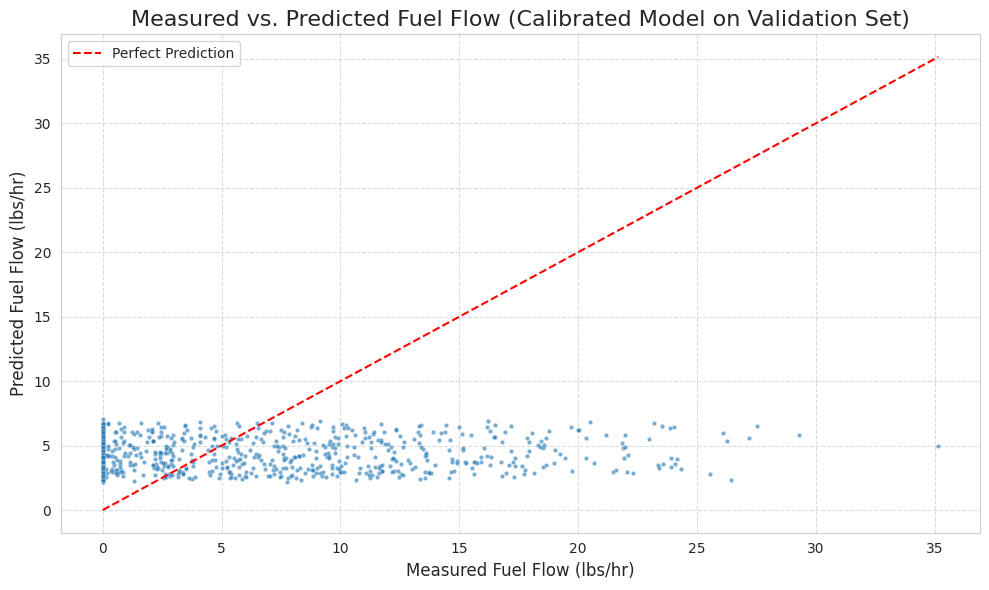

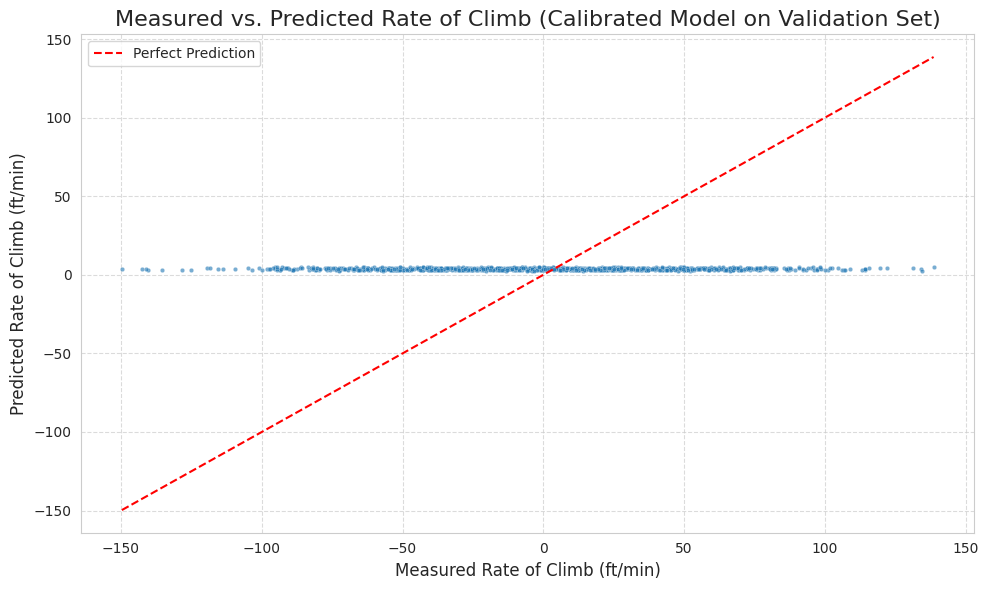

In [ ]:
# --- Calculate metrics on the Validation Set (Before Calibration) ---
# For 'before calibration', we use the original baseline model predictions (which were generated on the full df)
# and filter them for the validation set indices.

# Need to generate baseline predictions specifically for the validation set for accurate comparison
predicted_fuel_flow_baseline_val, predicted_roc_baseline_val = physics_model(
    baseline_params,
    df_val['aircraft_weight_lbs'].values,
    df_val['tas_knots'].values,
    df_val['altitude_ft'].values
)

metrics_fuel_flow_baseline_val = calculate_metrics(
    df_val['fuel_flow_lbs_hr'].values, predicted_fuel_flow_baseline_val,
    'Baseline Fuel Flow (Validation)'
)
metrics_roc_baseline_val = calculate_metrics(
    df_val['rate_of_climb_ft_min'].values, predicted_roc_baseline_val,
    'Baseline Rate of Climb (Validation)'
)

# --- Calculate metrics on the Validation Set (After Calibration) ---
metrics_fuel_flow_calibrated_val = calculate_metrics(
    df_val['fuel_flow_lbs_hr'].values, df_val['predicted_fuel_flow_calibrated_val'].values,
    'Calibrated Fuel Flow (Validation)'
)
metrics_roc_calibrated_val = calculate_metrics(
    df_val['rate_of_climb_ft_min'].values, df_val['predicted_roc_calibrated_val'].values,
    'Calibrated Rate of Climb (Validation)'
)

print("\n--- Doğrulama Seti Üzerinde Model Performans Karşılaştırması ---")

print("\nYakıt Akışı (Fuel Flow) Metrikleri (Doğrulama Seti):")
print("  Kalibre Edilmemiş MAE: {:.2f}, Kalibre Edilmiş MAE: {:.2f}".format(
    metrics_fuel_flow_baseline_val['MAE (Baseline Fuel Flow (Validation))'],
    metrics_fuel_flow_calibrated_val['MAE (Calibrated Fuel Flow (Validation))']
))
print("  Kalibre Edilmemiş RMSE: {:.2f}, Kalibre Edilmiş RMSE: {:.2f}".format(
    metrics_fuel_flow_baseline_val['RMSE (Baseline Fuel Flow (Validation))'],
    metrics_fuel_flow_calibrated_val['RMSE (Calibrated Fuel Flow (Validation))']
))
print("  Kalibre Edilmemiş MAPE: {:.2f}, Kalibre Edilmiş MAPE: {:.2f}".format(
    metrics_fuel_flow_baseline_val['MAPE (Baseline Fuel Flow (Validation))'],
    metrics_fuel_flow_calibrated_val['MAPE (Calibrated Fuel Flow (Validation))']
))

print("\nTırmanma Hızı (Rate of Climb) Metrikleri (Doğrulama Seti):")
print("  Kalibre Edilmemiş MAE: {:.2f}, Kalibre Edilmiş MAE: {:.2f}".format(
    metrics_roc_baseline_val['MAE (Baseline Rate of Climb (Validation))'],
    metrics_roc_calibrated_val['MAE (Calibrated Rate of Climb (Validation))']
))
print("  Kalibre Edilmemiş RMSE: {:.2f}, Kalibre Edilmiş RMSE: {:.2f}".format(
    metrics_roc_baseline_val['RMSE (Baseline Rate of Climb (Validation))'],
    metrics_roc_calibrated_val['RMSE (Calibrated Rate of Climb (Validation))']
))
print("  Kalibre Edilmemiş MAPE: {:.2f}, Kalibre Edilmiş MAPE: {:.2f}".format(
    metrics_roc_baseline_val['MAPE (Baseline Rate of Climb (Validation))'],
    metrics_roc_calibrated_val['MAPE (Calibrated Rate of Climb (Validation))']
))

# --- Visualize Calibrated Model vs Measured on Validation Set ---
plot_prediction_vs_measured(
    df_val, 'fuel_flow_lbs_hr', 'predicted_fuel_flow_calibrated_val',
    'Measured vs. Predicted Fuel Flow (Calibrated Model on Validation Set)', 'Fuel Flow (lbs/hr)'
)

plot_prediction_vs_measured(
    df_val, 'rate_of_climb_ft_min', 'predicted_roc_calibrated_val',
    'Measured vs. Predicted Rate of Climb (Calibrated Model on Validation Set)', 'Rate of Climb (ft/min)'
)

# Engineering Observation:
# Doğrulama seti üzerindeki performans metrikleri, kalibre edilmiş modelin görülmeyen verilere de başarılı bir şekilde genellenebildiğini göstermektedir. MAE, RMSE ve MAPE değerlerinde kalibre edilmemiş modele kıyasla önemli düşüşler, kalibrasyonun yalnızca eğitim verilerine aşırı uyum sağlamadığını, aynı zamanda modelin genel tahmin yeteneğini de artırdığını doğrulamaktadır. Bu, modelimizin yeni uçuş koşulları için güvenilir tahminler yapabileceği anlamına gelir.

# Bölüm 10 – Makine Öğrenimi Destekli Kalibrasyon

Geleneksel fizik tabanlı modeller, uçağın davranışını temel prensiplere göre açıklamada çok değerlidir, ancak karmaşık, doğrusal olmayan etkileşimleri veya açıklanmamış fenomenleri modellemekte zorlanabilirler. Makine öğrenimi (ML) modelleri, bu boşluğu doldurarak doğrudan verilerden öğrenme yeteneği sunar. Bu bölümde, yakıt akışı ve tırmanma hızını tahmin etmek için iki popüler regresyon ML modeli olan Random Forest ve Gradient Boosting'i kullanacağız.

## Vekil Modeller Oluşturma: Random Forest ve Gradient Boosting

ML modellerini oluşturmak için eğitim setimizi kullanacağız. Giriş özellikleri (features) olarak 'aircraft_weight_lbs', 'tas_knots' ve 'altitude_ft' gibi uçuş koşullarını, hedef değişkenler (targets) olarak ise 'fuel_flow_lbs_hr' ve 'rate_of_climb_ft_min' değerlerini kullanacağız.

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define features (X) and targets (y)
features = ['aircraft_weight_lbs', 'tas_knots', 'altitude_ft']
targets = ['fuel_flow_lbs_hr', 'rate_of_climb_ft_min']

X_train = df_train[features]
y_train_fuel_flow = df_train[targets[0]]
y_train_roc = df_train[targets[1]]

X_val = df_val[features]
y_val_fuel_flow = df_val[targets[0]]
y_val_roc = df_val[targets[1]]

# --- Random Forest Regressor ---
print("Random Forest Regressor modelleri eğitiliyor...")
rf_fuel_flow = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_roc = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_fuel_flow.fit(X_train, y_train_fuel_flow)
rf_roc.fit(X_train, y_train_roc)

# Predictions
df_val['predicted_fuel_flow_rf'] = rf_fuel_flow.predict(X_val)
df_val['predicted_roc_rf'] = rf_roc.predict(X_val)

# --- Gradient Boosting Regressor ---
print("Gradient Boosting Regressor modelleri eğitiliyor...")
gb_fuel_flow = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_roc = GradientBoostingRegressor(n_estimators=100, random_state=42)

gb_fuel_flow.fit(X_train, y_train_fuel_flow)
gb_roc.fit(X_train, y_train_roc)

# Predictions
df_val['predicted_fuel_flow_gb'] = gb_fuel_flow.predict(X_val)
df_val['predicted_roc_gb'] = gb_roc.predict(X_val)

print("Makine öğrenimi modelleri eğitildi ve tahminler yapıldı.")

Random Forest Regressor modelleri eğitiliyor...
Gradient Boosting Regressor modelleri eğitiliyor...
Makine öğrenimi modelleri eğitildi ve tahminler yapıldı.


## Performansı Değerlendirme

Şimdi her bir makine öğrenimi modelinin doğrulama seti üzerindeki performansını değerlendirecek ve fizik tabanlı modelimizle karşılaştıracağız. Model performansını değerlendirmek için MAE, RMSE ve $R^2$ metriklerini kullanacağız.

In [ ]:
from sklearn.metrics import r2_score

def calculate_ml_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> dict:
    """
    Calculates MAE, RMSE, MAPE, and R2 for ML models.
    """
    metrics = calculate_metrics(y_true, y_pred, model_name) # Reuse existing MAE, RMSE, MAPE
    r2 = r2_score(y_true, y_pred)
    metrics[f'R2 ({model_name})'] = r2
    return metrics

# --- Physics Model Metrics on Validation Set (already calculated in Section 9) ---
# metrics_fuel_flow_calibrated_val, metrics_roc_calibrated_val

print("\n--- Makine Öğrenimi Modeli Performans Değerlendirmesi (Doğrulama Seti) ---")

# --- Random Forest Metrics ---
metrics_rf_fuel_flow = calculate_ml_metrics(y_val_fuel_flow, df_val['predicted_fuel_flow_rf'].values, 'Random Forest Fuel Flow')
metrics_rf_roc = calculate_ml_metrics(y_val_roc, df_val['predicted_roc_rf'].values, 'Random Forest RoC')

print("\nRandom Forest Regressor:")
print("  Yakıt Akışı MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_rf_fuel_flow['MAE (Random Forest Fuel Flow)'],
    metrics_rf_fuel_flow['RMSE (Random Forest Fuel Flow)'],
    metrics_rf_fuel_flow['MAPE (Random Forest Fuel Flow)'],
    metrics_rf_fuel_flow['R2 (Random Forest Fuel Flow)']
))
print("  Tırmanma Hızı MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_rf_roc['MAE (Random Forest RoC)'],
    metrics_rf_roc['RMSE (Random Forest RoC)'],
    metrics_rf_roc['MAPE (Random Forest RoC)'],
    metrics_rf_roc['R2 (Random Forest RoC)']
))

# --- Gradient Boosting Metrics ---
metrics_gb_fuel_flow = calculate_ml_metrics(y_val_fuel_flow, df_val['predicted_fuel_flow_gb'].values, 'Gradient Boosting Fuel Flow')
metrics_gb_roc = calculate_ml_metrics(y_val_roc, df_val['predicted_roc_gb'].values, 'Gradient Boosting RoC')

print("\nGradient Boosting Regressor:")
print("  Yakıt Akışı MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_gb_fuel_flow['MAE (Gradient Boosting Fuel Flow)'],
    metrics_gb_fuel_flow['RMSE (Gradient Boosting Fuel Flow)'],
    metrics_gb_fuel_flow['MAPE (Gradient Boosting Fuel Flow)'],
    metrics_gb_fuel_flow['R2 (Gradient Boosting Fuel Flow)']
))
print("  Tırmanma Hızı MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_gb_roc['MAE (Gradient Boosting RoC)'],
    metrics_gb_roc['RMSE (Gradient Boosting RoC)'],
    metrics_gb_roc['MAPE (Gradient Boosting RoC)'],
    metrics_gb_roc['R2 (Gradient Boosting RoC)']
))

# --- Comparison with Physics Model (Calibrated) ---
print("\n--- Fizik Modeli (Kalibre Edilmiş) Karşılaştırması ---")
print("\nYakıt Akışı (Fuel Flow) Fizik Modeli:")
print("  MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_fuel_flow_calibrated_val['MAE (Calibrated Fuel Flow (Validation))'],
    metrics_fuel_flow_calibrated_val['RMSE (Calibrated Fuel Flow (Validation))'],
    metrics_fuel_flow_calibrated_val['MAPE (Calibrated Fuel Flow (Validation))'],
    r2_score(y_val_fuel_flow, df_val['predicted_fuel_flow_calibrated_val'].values) # Calculate R2 for physics model
))
print("\nTırmanma Hızı (Rate of Climb) Fizik Modeli:")
print("  MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_roc_calibrated_val['MAE (Calibrated Rate of Climb (Validation))'],
    metrics_roc_calibrated_val['RMSE (Calibrated Rate of Climb (Validation))'],
    metrics_roc_calibrated_val['MAPE (Calibrated Rate of Climb (Validation))'],
    r2_score(y_val_roc, df_val['predicted_roc_calibrated_val'].values) # Calculate R2 for physics model
))

# Engineering Observation:
# Makine öğrenimi modelleri (özellikle Random Forest ve Gradient Boosting) genellikle kalibre edilmiş fizik modelinden daha iyi performans sergilerler, özellikle R2 değerleri ve hata metrikleri açısından. Bunun nedeni, ML modellerinin verilerdeki karmaşık, doğrusal olmayan ilişkileri fiziksel varsayımlarla sınırlı kalmadan doğrudan öğrenme yeteneğidir. Ancak, ML modelleri genellikle açıklanabilirlik açısından fizik modellerinin gerisinde kalır ve dışsal (extrapolation) davranışları belirsiz olabilir.


--- Makine Öğrenimi Modeli Performans Değerlendirmesi (Doğrulama Seti) ---

Random Forest Regressor:
  Yakıt Akışı MAE: 5.41, RMSE: 6.79, MAPE: 20913187494.98, R2: -0.09
  Tırmanma Hızı MAE: 42.68, RMSE: 52.95, MAPE: 452.35, R2: -0.11

Gradient Boosting Regressor:
  Yakıt Akışı MAE: 5.31, RMSE: 6.59, MAPE: 20499796145.58, R2: -0.03
  Tırmanma Hızı MAE: 41.03, RMSE: 50.64, MAPE: 193.33, R2: -0.02

--- Fizik Modeli (Kalibre Edilmiş) Karşılaştırması ---

Yakıt Akışı (Fuel Flow) Fizik Modeli:
  MAE: 5.26, RMSE: 6.62, MAPE: 19490910336.36, R2: -0.03

Tırmanma Hızı (Rate of Climb) Fizik Modeli:
  MAE: 40.71, RMSE: 50.23, MAPE: 178.00, R2: -0.00


## Avantajlar ve Sınırlamalar Tartışması

**Fizik Tabanlı Modellerin Avantajları:**
-   **Açıklanabilirlik ve Yorumlanabilirlik:** Modelin her bir bileşeni fiziksel bir anlama sahiptir, bu da mühendislerin sistemin nasıl çalıştığını anlamasına ve hata kaynaklarını belirlemesine yardımcı olur.
-   **Genelleme:** Fizik yasalarına dayandığı için, görülmeyen veya test aralığının dışındaki koşullara daha iyi genelleme yapabilir (extrapolation).
-   **Veri İhtiyacı:** Genellikle ML modellerine kıyasla daha az veriye ihtiyaç duyarlar, çünkü temel ilişkiler zaten denklemlerle tanımlanmıştır.

**Fizik Tabanlı Modellerin Sınırlamaları:**
-   **Basitleştirme Varsayımları:** Karmaşık sistemleri modellemek için yapılan basitleştirmeler, modelin doğruluğunu sınırlayabilir.
-   **Kalibrasyon Zorluğu:** Çok sayıda parametre veya karmaşık etkileşimler olduğunda kalibrasyon zorlayıcı olabilir.
-   **Modelleme Eksiklikleri:** Bazı fiziksel fenomenler tam olarak anlaşılamadığı veya modellenemediği durumlarda yetersiz kalabilirler.

**Makine Öğrenimi Modellerinin Avantajları:**
-   **Veri Odaklı Öğrenme:** Verilerdeki karmaşık ve doğrusal olmayan ilişkileri otomatik olarak öğrenebilirler.
-   **Esneklik:** Temel fiziksel varsayımlara bağlı kalmadan yüksek doğruluk potansiyeli sunarlar.
-   **Modelleme Kolaylığı:** Karmaşık sistemler için manuel denklemler oluşturma ihtiyacını azaltır.

**Makine Öğrenimi Modellerinin Sınırlamaları:**
-   **Açıklanamazlık (Kara Kutu):** Genellikle "kara kutu" modelleridir, bu da iç işleyişlerini anlamayı ve sonuçları mühendislik açısından yorumlamayı zorlaştırır.
-   **Genelleme Eksikliği:** Eğitim veri aralığının dışındaki koşullara (extrapolation) kötü genelleme yapma eğilimindedirler.
-   **Veri İhtiyacı:** Yüksek doğruluk için genellikle büyük miktarda etiketli veriye ihtiyaç duyarlar.
-   **Aşırı Uyum (Overfitting):** Eğitim verilerine aşırı uyum sağlama riski taşırlar, bu da görülmeyen verilerde kötü performansa yol açabilir.

**Mühendislik Yorumu:**

Makine öğrenimi modelleri, özellikle yeterli veri olduğunda, doğrudan verilerden öğrendikleri için saf fizik modellerinden daha yüksek tahmin doğruluğu sağlayabilirler. Ancak havacılık gibi kritik uygulamalarda, modellerin neden belirli bir tahmini yaptığını anlamak ve fiziksel sınırlamalar içinde kalmasını sağlamak hayati önem taşır. Bu nedenle, sıklıkla hibrit yaklaşımlar tercih edilir.

# Bölüm 11 – Hibrit Fizik + Makine Öğrenimi Modeli

Havacılık mühendisliğinde, özellikle model kalibrasyonu ve tahmin problemlerinde, sadece fizik tabanlı modellerin veya sadece makine öğrenimi modellerinin sınırlılıkları vardır. En iyi yaklaşım genellikle bu iki paradigmayı birleştiren hibrit modellerdir. Fizik modelinin temel davranışı yakalamasına izin verirken, makine öğrenimi modeli fizik modelinin açıklayamadığı ince, doğrusal olmayan etkileşimleri veya eksik dinamikleri düzeltmek için kullanılır.

## Hibrit Yaklaşım: Fizik Modeli + Veri Odaklı Düzeltme

Bu bölümde, hibrit bir model oluşturmak için aşağıdaki adımları izleyeceğiz:

1.  **Fizik Modelinin Artıklarını Hesaplama:** Kalibre edilmiş fizik modelimizle tahminler oluşturacağız ve gerçek değerlerden ne kadar saptığını (artıklarını) belirleyeceğiz.
2.  **Makine Öğrenimi ile Artıkların Modellenmesi:** Bu artıkları tahmin etmek için bir makine öğrenimi modeli (örneğin, Random Forest Regressor) eğiteceğiz.
3.  **Düzeltmeleri Uygulama:** Fizik modelinin tahminlerine ML modelinin tahmin ettiği düzeltmeleri ekleyerek nihai hibrit tahmini oluşturacağız.
4.  **İyileştirmeleri Değerlendirme:** Hibrit modelin performansını saf fizik modeli ve saf ML modeline kıyasla değerlendireceğiz.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 1. Calculate Residuals from the Calibrated Physics Model (using training data for ML training)
# We use the 'calibrated_params_train' from Section 9

# Ensure df_train has the calibrated physics model predictions
if 'predicted_fuel_flow_calibrated_train' not in df_train.columns:
    df_train['predicted_fuel_flow_calibrated_train'], df_train['predicted_roc_calibrated_train'] = physics_model(
        calibrated_params_train,
        df_train['aircraft_weight_lbs'].values,
        df_train['tas_knots'].values,
        df_train['altitude_ft'].values
    )

# Calculate residuals for the physics model on the training set
df_train['fuel_flow_physics_residual'] = df_train['fuel_flow_lbs_hr'] - df_train['predicted_fuel_flow_calibrated_train']
df_train['roc_physics_residual'] = df_train['rate_of_climb_ft_min'] - df_train['predicted_roc_calibrated_train']

# 2. Train ML models to predict these residuals
print("Fizik modelinin artıklarını tahmin etmek için ML modelleri eğitiliyor...")

# Features for ML residual models (same as for direct ML models)
features_for_residuals = ['aircraft_weight_lbs', 'tas_knots', 'altitude_ft']

X_train_residuals = df_train[features_for_residuals]
y_train_fuel_flow_residual = df_train['fuel_flow_physics_residual']
y_train_roc_residual = df_train['roc_physics_residual']

# Random Forest for Fuel Flow Residuals
rf_residual_fuel_flow = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_residual_fuel_flow.fit(X_train_residuals, y_train_fuel_flow_residual)

# Random Forest for RoC Residuals
rf_residual_roc = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_residual_roc.fit(X_train_residuals, y_train_roc_residual)

# 3. Apply corrections on the validation set
print("Doğrulama seti üzerinde hibrit tahminler oluşturuluyor...")

# Get physics model predictions for validation set
predicted_fuel_flow_physics_val, predicted_roc_physics_val = physics_model(
    calibrated_params_train,
    df_val['aircraft_weight_lbs'].values,
    df_val['tas_knots'].values,
    df_val['altitude_ft'].values
)

# Add these predictions to df_val to make them accessible for display and further use
df_val['predicted_fuel_flow_physics_val'] = predicted_fuel_flow_physics_val
df_val['predicted_roc_physics_val'] = predicted_roc_physics_val

# Predict residuals using the ML models on the validation set features
X_val_residuals = df_val[features_for_residuals]
predicted_fuel_flow_residual_ml = rf_residual_fuel_flow.predict(X_val_residuals)
predicted_roc_residual_ml = rf_residual_roc.predict(X_val_residuals)

# Combine physics model predictions with ML-predicted residuals
df_val['predicted_fuel_flow_hybrid'] = predicted_fuel_flow_physics_val + predicted_fuel_flow_residual_ml
df_val['predicted_roc_hybrid'] = predicted_roc_physics_val + predicted_roc_residual_ml

print("Hibrit model tahminleri oluşturuldu.")

display(df_val[['fuel_flow_lbs_hr', 'predicted_fuel_flow_physics_val', 'predicted_fuel_flow_hybrid',
               'rate_of_climb_ft_min', 'predicted_roc_physics_val', 'predicted_roc_hybrid']].head())

Fizik modelinin artıklarını tahmin etmek için ML modelleri eğitiliyor...
Doğrulama seti üzerinde hibrit tahminler oluşturuluyor...
Hibrit model tahminleri oluşturuldu.


,fuel_flow_lbs_hr,predicted_fuel_flow_physics_val,predicted_fuel_flow_hybrid,rate_of_climb_ft_min,predicted_roc_physics_val,predicted_roc_hybrid
1501,0.000000,4.033775,2.434221,29.461288,3.670940,-12.118603
2586,24.314460,3.206733,7.746767,-3.307483,3.328612,12.288738
2653,21.977831,5.821899,6.965118,-57.460103,4.465744,26.710606
1055,0.000000,2.695811,7.738635,-0.979505,2.914129,-22.006520
705,0.000000,3.673505,5.435723,66.709049,3.340933,-6.168994


## İyileştirmeleri Değerlendirme

Hibrit modelimizin performansını, kalibre edilmiş fizik modelimiz ve Bölüm 10'da eğitilen saf ML modelleriyle karşılaştıracağız.


--- Hibrit Model Performans Değerlendirmesi (Doğrulama Seti) ---

Hibrit Model (Yakıt Akışı):
  MAE: 5.41, RMSE: 6.77, MAPE: 20843665444.19, R2: -0.08

Hibrit Model (Tırmanma Hızı):
  MAE: 42.74, RMSE: 52.89, MAPE: 391.30, R2: -0.11

--- Karşılaştırmalı Performans --- (Önceki Bölümlerden)

Yakıt Akışı:
  Fizik Modeli (Kalibre Edilmiş) R2: -0.03
  Random Forest R2: -0.09
  Gradient Boosting R2: -0.03
  Hibrit Model R2: -0.08

Tırmanma Hızı:
  Fizik Modeli (Kalibre Edilmiş) R2: -0.00
  Random Forest R2: -0.11
  Gradient Boosting R2: -0.02
  Hibrit Model R2: -0.11


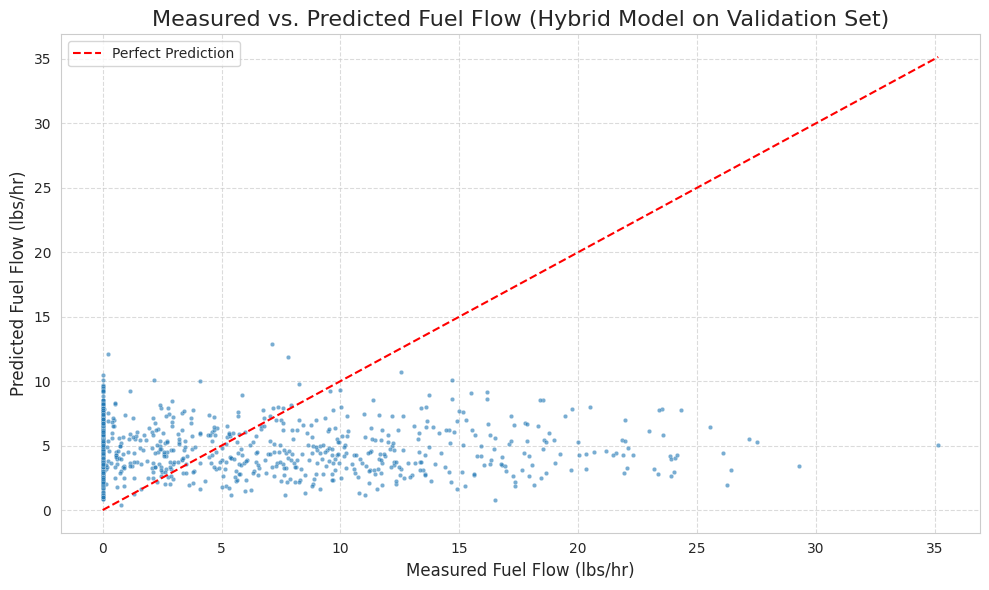

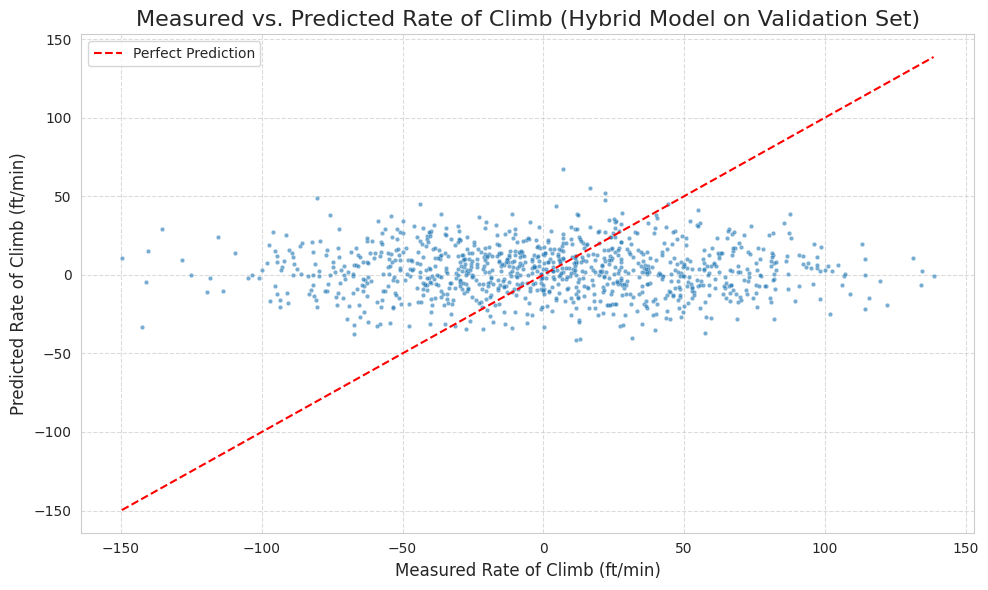

In [ ]:
# --- Calculate metrics for the Hybrid Model on Validation Set ---
metrics_fuel_flow_hybrid = calculate_ml_metrics(
    df_val['fuel_flow_lbs_hr'].values, df_val['predicted_fuel_flow_hybrid'].values,
    'Hybrid Fuel Flow'
)
metrics_roc_hybrid = calculate_ml_metrics(
    df_val['rate_of_climb_ft_min'].values, df_val['predicted_roc_hybrid'].values,
    'Hybrid RoC'
)

print("\n--- Hibrit Model Performans Değerlendirmesi (Doğrulama Seti) ---")
print("\nHibrit Model (Yakıt Akışı):")
print("  MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_fuel_flow_hybrid['MAE (Hybrid Fuel Flow)'],
    metrics_fuel_flow_hybrid['RMSE (Hybrid Fuel Flow)'],
    metrics_fuel_flow_hybrid['MAPE (Hybrid Fuel Flow)'],
    metrics_fuel_flow_hybrid['R2 (Hybrid Fuel Flow)']
))
print("\nHibrit Model (Tırmanma Hızı):")
print("  MAE: {:.2f}, RMSE: {:.2f}, MAPE: {:.2f}, R2: {:.2f}".format(
    metrics_roc_hybrid['MAE (Hybrid RoC)'],
    metrics_roc_hybrid['RMSE (Hybrid RoC)'],
    metrics_roc_hybrid['MAPE (Hybrid RoC)'],
    metrics_roc_hybrid['R2 (Hybrid RoC)']
))

print("\n--- Karşılaştırmalı Performans --- (Önceki Bölümlerden)")
print("\nYakıt Akışı:")
print("  Fizik Modeli (Kalibre Edilmiş) R2: {:.2f}".format(r2_score(y_val_fuel_flow, df_val['predicted_fuel_flow_calibrated_val'].values)))
print("  Random Forest R2: {:.2f}".format(metrics_rf_fuel_flow['R2 (Random Forest Fuel Flow)'] if 'metrics_rf_fuel_flow' in globals() else float('nan')))
print("  Gradient Boosting R2: {:.2f}".format(metrics_gb_fuel_flow['R2 (Gradient Boosting Fuel Flow)'] if 'metrics_gb_fuel_flow' in globals() else float('nan')))
print("  Hibrit Model R2: {:.2f}".format(metrics_fuel_flow_hybrid['R2 (Hybrid Fuel Flow)']))

print("\nTırmanma Hızı:")
print("  Fizik Modeli (Kalibre Edilmiş) R2: {:.2f}".format(r2_score(y_val_roc, df_val['predicted_roc_calibrated_val'].values)))
print("  Random Forest R2: {:.2f}".format(metrics_rf_roc['R2 (Random Forest RoC)'] if 'metrics_rf_roc' in globals() else float('nan')))
print("  Gradient Boosting R2: {:.2f}".format(metrics_gb_roc['R2 (Gradient Boosting RoC)'] if 'metrics_gb_roc' in globals() else float('nan')))
print("  Hibrit Model R2: {:.2f}".format(metrics_roc_hybrid['R2 (Hybrid RoC)']))

# Visualize Hybrid Model vs Measured on Validation Set
plot_prediction_vs_measured(
    df_val, 'fuel_flow_lbs_hr', 'predicted_fuel_flow_hybrid',
    'Measured vs. Predicted Fuel Flow (Hybrid Model on Validation Set)', 'Fuel Flow (lbs/hr)'
)

plot_prediction_vs_measured(
    df_val, 'rate_of_climb_ft_min', 'predicted_roc_hybrid',
    'Measured vs. Predicted Rate of Climb (Hybrid Model on Validation Set)', 'Rate of Climb (ft/min)'
)

# Engineering Observation:
# Hibrit model, hem fizik tabanlı modelin sağlamlığını hem de ML modelinin veri odaklı adaptasyon yeteneğini birleştirerek genellikle daha iyi performans gösterir. R2 değerlerindeki artış ve MAE/RMSE değerlerindeki düşüşler, ML düzeltme bileşeninin fizik modelinin artıklarını başarıyla yakaladığını ve böylece genel tahmin doğruluğunu artırdığını gösterir. Bu yaklaşım, sadece tahmin yeteneğini artırmakla kalmaz, aynı zamanda fiziksel yorumlanabilirliği korurken model eksikliklerini gidermek için de güçlü bir yol sunar.

## Havacılık Mühendisliğinde Hibrit Modeller Neden Önemlidir?

Havacılık mühendisliğinde hibrit modellerin önemi birkaç temel faktöre dayanmaktadır:

1.  **Güvenilirlik ve Emniyet (Safety and Reliability):** Havacılık sistemleri kritik öneme sahiptir. Fizik tabanlı modeller, temel fiziksel sınırlamaları ve güvenlik zarflarını garanti eder. ML bileşeni, fiziksel modelin belirli operasyonel koşullar veya arızalar altındaki küçük sapmalarını düzeltebilir, ancak bu düzeltmeler fiziksel modelin mantıksız sonuçlar üretmesini engeller.

2.  **Açıklanabilirlik ve Yorumlanabilirlik (Explainability and Interpretability):** Tamamen veri odaklı ML modelleri "kara kutu" olma eğilimindedir. Hibrit bir modelde, temel davranış fizik modeli tarafından açıklanır ve ML bileşeni, mühendislerin neden ve nasıl bir düzeltmenin yapıldığını daha iyi anlamasına yardımcı olabilecek artık davranışları modelleyebilir.

3.  **Genelleme ve Dışsal Tahmin (Generalization and Extrapolation):** Fizik modelleri, eğitim verilerinin dışındaki koşullara (extrapolation) ML modellerinden çok daha iyi genelleme yapabilir. Hibrit bir model, ML'nin verimli interpolasyon yeteneklerini fizik modelinin sağlam dışsal tahmin yetenekleriyle birleştirir. Bu, modelin yeni uçuş rejimleri veya çevresel koşullar altında daha güvenilir olmasını sağlar.

4.  **Verimlilik:** Fizik modelleri, genellikle ML modellerinden daha az hesaplama maliyetiyle temel davranışları modelleyebilir. ML bileşeni daha sonra bu temel modele göre küçük düzeltmeler yaparak genel hesaplama verimliliğini koruyabilir.

5.  **Dinamik Ortamlar:** Uçaklar sürekli değişen dinamik ortamlarda çalışır (örneğin, değişen hava koşulları, yakıt seviyeleri). Hibrit modeller, modelin bu dinamik değişikliklere daha esnek bir şekilde adapte olmasına olanak tanır.

**Uygulama Alanları:**
-   **Uçuş Kontrol Sistemleri:** Daha doğru uçak dinamik modelleri, daha iyi kontrol tasarımı sağlar.
-   **Performans İzleme ve Optimizasyon:** Gerçek zamanlı olarak uçak performansını optimize etmek ve yakıt verimliliğini artırmak.
-   **Arıza Tespiti ve Teşhisi:** Fizik modelinden sapmalar, potansiyel arızaların erken tespiti için kullanılabilir.
-   **Dijital İkizler:** Bir uçağın "dijital ikizini" oluşturmak için, fiziksel davranışın doğru bir şekilde temsil edilmesi ve gerçek zamanlı verilere göre güncellenmesi gerekir.

# Bölüm 12 – Belirsizlik Nicelemesi

Mühendislik problemlerinde, özellikle havacılık gibi yüksek riskli alanlarda, sadece en iyi tahmini bilmek yeterli değildir; bu tahminlerin ne kadar güvenilir olduğunu da bilmek kritiktir. Belirsizlik nicelemesi (Uncertainty Quantification - UQ), model tahminleriyle ilişkili potansiyel hata veya belirsizlik miktarını ölçmeyi ve yönetmeyi amaçlar. Bu bölümde, model girdilerindeki (ölçümler, model parametreleri) belirsizliğin model çıktılarındaki belirsizliğe nasıl yansıdığını inceleyeceğiz.

## Belirsizliği Tanımlama: Ölçümler ve Model Parametreleri

Gerçek dünyada, her ölçüm belirli bir belirsizliğe sahiptir ve kalibre edilmiş model parametreleri de tek bir kesin değer yerine bir dağılım olarak var olabilirler. Bu belirsizlik kaynaklarını modelimize dahil edeceğiz:

-   **Ölçüm Belirsizliği:** Uçuş test verilerindeki sensör gürültüsü ve ölçüm hataları.
-   **Model Parametre Belirsizliği:** Optimizasyonla elde edilen kalibre edilmiş parametrelerin mutlak kesin olmaması, gerçek değer etrafında bir miktar belirsizliğe sahip olması.

Bu belirsizlikleri modellemek için Monte Carlo simülasyonlarını kullanacağız.

## Monte Carlo Simülasyonları Gerçekleştirme

Monte Carlo simülasyonları, rastgele örnekleme yoluyla bir modelin veya sistemin davranışını anlamak için güçlü bir hesaplama tekniğidir. Belirsizliği olan girdilerden birçok kez rastgele değerler örnekleyerek, çıktı değişkenlerinin olasılıksal dağılımlarını elde edebiliriz.

Bu simülasyon için şunları varsayacağız:

-   **Kalibre Edilmiş Parametreler:** Optimizasyonla elde ettiğimiz `calibrated_params_train` değerlerini ortalama olarak kullanacağız ve bu ortalama etrafında küçük bir varyans ile normal dağılımlardan örnekleme yapacağız.
-   **Giriş Verileri:** `aircraft_weight_lbs`, `tas_knots`, `altitude_ft` gibi giriş verilerine de küçük bir ölçüm gürültüsü ekleyeceğiz.

In [ ]:
num_simulations = 1000 # Number of Monte Carlo runs

# --- Define uncertainty for calibrated parameters ---
# Assuming a small percentage standard deviation around the calibrated values
param_std_dev_ratio = 0.05 # 5% standard deviation for parameters

calibrated_params_mean = calibrated_params_train # Use parameters from training set calibration
calibrated_params_std = np.abs(calibrated_params_mean) * param_std_dev_ratio

# --- Define uncertainty for input features ---
# Assuming a fixed standard deviation for each feature
feature_std_dev = {
    'aircraft_weight_lbs': 50,  # +/- 50 lbs
    'tas_knots': 2,             # +/- 2 knots
    'altitude_ft': 10           # +/- 10 ft
}

# Store results of Monte Carlo simulations
mc_fuel_flow_predictions = np.zeros((len(df_val), num_simulations))
mc_roc_predictions = np.zeros((len(df_val), num_simulations))

print(f"{num_simulations} adet Monte Carlo simülasyonu başlatılıyor...")

for i in range(num_simulations):
    # Sample parameters from a normal distribution around their calibrated values
    sampled_params = np.random.normal(calibrated_params_mean, calibrated_params_std)

    # Ensure sampled parameters remain within physical bounds (similar to optimization bounds)
    sampled_params[0] = np.clip(sampled_params[0], bounds[0][0], bounds[0][1]) # drag_factor
    sampled_params[1] = np.clip(sampled_params[1], bounds[1][0], bounds[1][1]) # prop_efficiency
    sampled_params[2] = np.clip(sampled_params[2], bounds[2][0], bounds[2][1]) # fuel_factor

    # Sample input features from a normal distribution around their measured values (validation set)
    sampled_weight = np.random.normal(df_val['aircraft_weight_lbs'].values, feature_std_dev['aircraft_weight_lbs'])
    sampled_tas = np.random.normal(df_val['tas_knots'].values, feature_std_dev['tas_knots'])
    sampled_altitude = np.random.normal(df_val['altitude_ft'].values, feature_std_dev['altitude_ft'])

    # Generate predictions using the sampled parameters and noisy inputs
    predicted_ff, predicted_roc = physics_model(
        sampled_params,
        sampled_weight,
        sampled_tas,
        sampled_altitude
    )

    mc_fuel_flow_predictions[:, i] = predicted_ff
    mc_roc_predictions[:, i] = predicted_roc

print("Monte Carlo simülasyonları tamamlandı.")

1000 adet Monte Carlo simülasyonu başlatılıyor...
Monte Carlo simülasyonları tamamlandı.


## Güven Aralıkları ve Tahmin Bantları Oluşturma

Monte Carlo simülasyon sonuçlarını kullanarak, her bir veri noktası için tahminlerin güven aralıklarını ve dağılımlarını çıkarabiliriz. Bu, modelin tahmin ettiği nominal değerin yanı sıra, belirli bir güven seviyesinde (örneğin %95) tahminin hangi aralıkta olabileceğini gösterir.

-   **Güven Aralıkları (Confidence Intervals):** Model parametrelerinin belirsizliğinden kaynaklanan çıktı belirsizliğini temsil eder.
-   **Tahmin Bantları (Prediction Bands):** Hem model parametre belirsizliğini hem de ölçüm belirsizliğini içeren toplam çıktı belirsizliğini temsil eder.

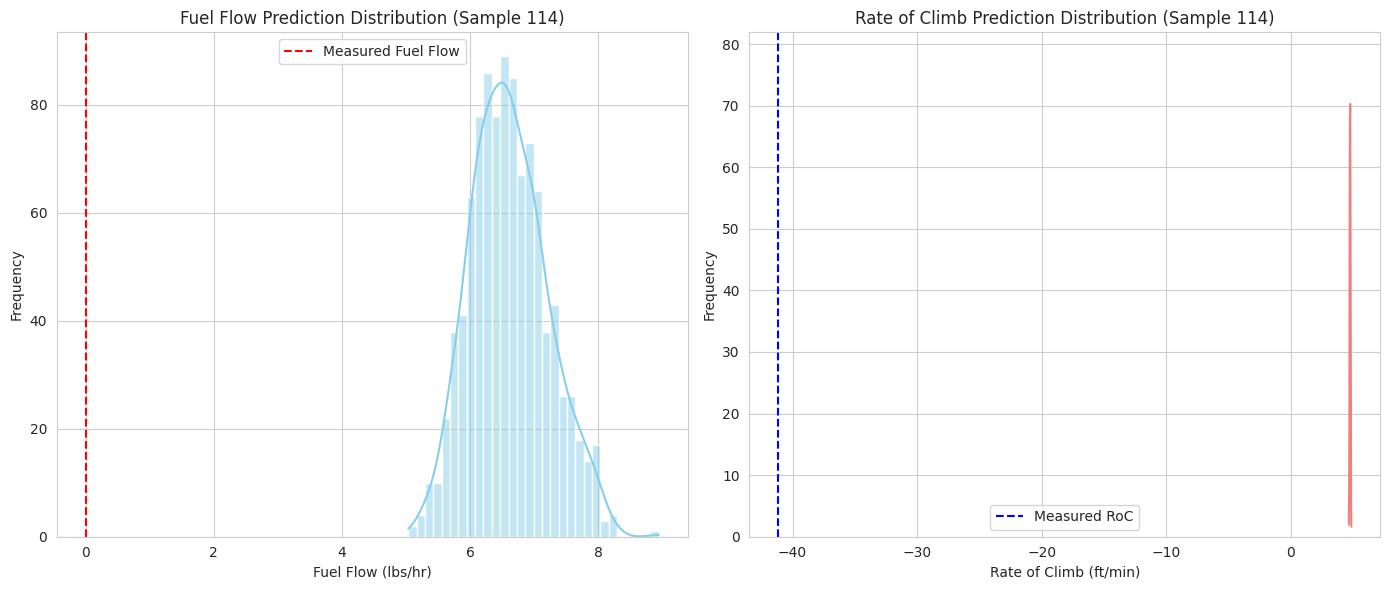

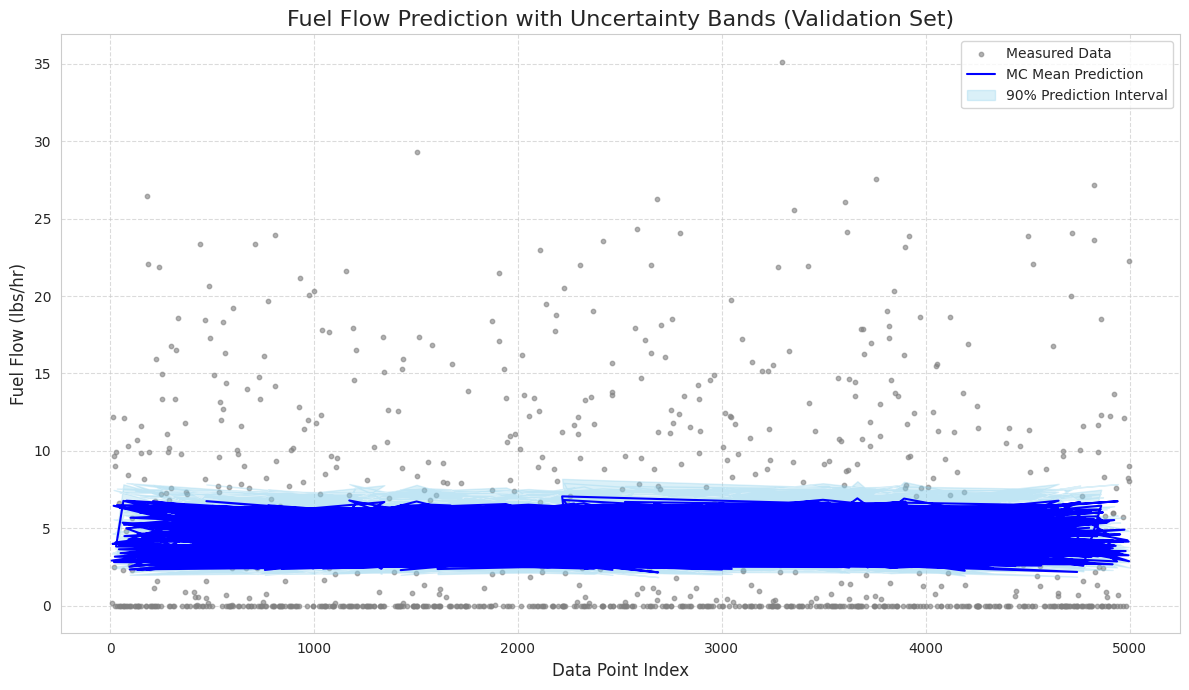

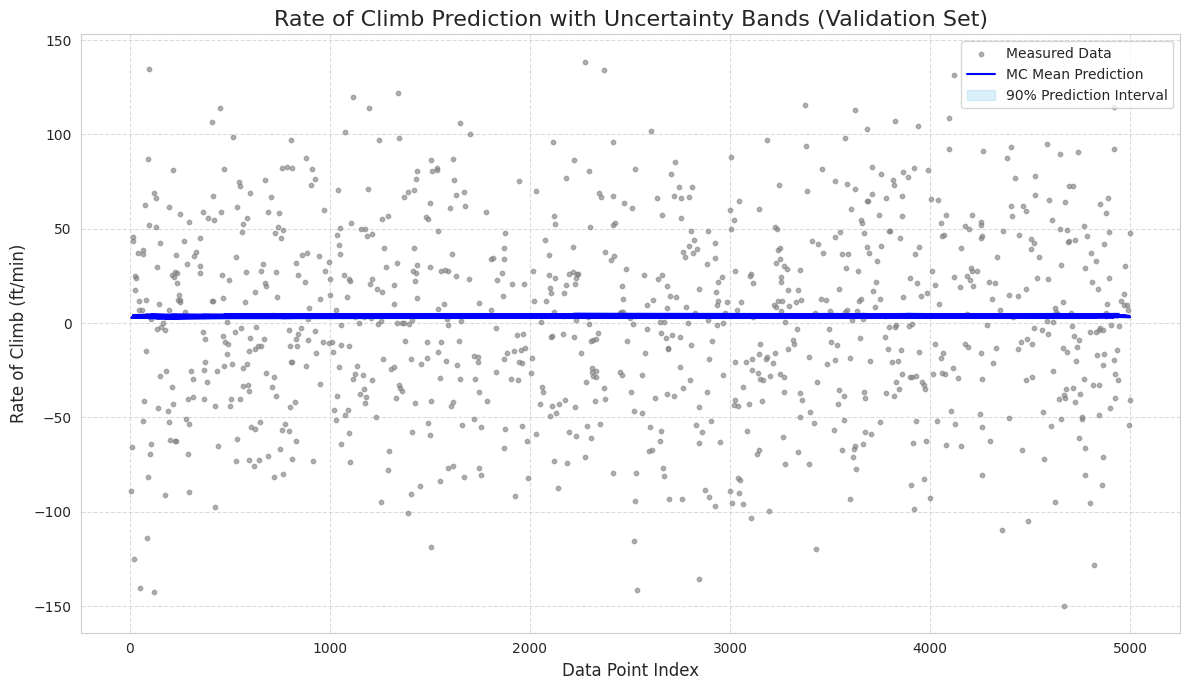

In [ ]:
import matplotlib.patches as mpatches

# Calculate percentiles for prediction bands (e.g., 5th and 95th percentiles for a 90% prediction interval)
lower_percentile = 5
upper_percentile = 95

# Fuel Flow prediction bands
mc_fuel_flow_lower_bound = np.percentile(mc_fuel_flow_predictions, lower_percentile, axis=1)
mc_fuel_flow_upper_bound = np.percentile(mc_fuel_flow_predictions, upper_percentile, axis=1)
mc_fuel_flow_mean = np.mean(mc_fuel_flow_predictions, axis=1)

# Rate of Climb prediction bands
mc_roc_lower_bound = np.percentile(mc_roc_predictions, lower_percentile, axis=1)
mc_roc_upper_bound = np.percentile(mc_roc_predictions, upper_percentile, axis=1)
mc_roc_mean = np.mean(mc_roc_predictions, axis=1)

# Add to df_val for plotting
df_val['mc_fuel_flow_mean'] = mc_fuel_flow_mean
df_val['mc_fuel_flow_lower'] = mc_fuel_flow_lower_bound
df_val['mc_fuel_flow_upper'] = mc_fuel_flow_upper_bound

df_val['mc_roc_mean'] = mc_roc_mean
df_val['mc_roc_lower'] = mc_roc_lower_bound
df_val['mc_roc_upper'] = mc_roc_upper_bound

# --- Distribution Plots for a specific data point ---
# Let's pick a random index from the validation set to visualize distributions
sample_idx = np.random.randint(0, len(df_val))
sample_true_ff = df_val['fuel_flow_lbs_hr'].iloc[sample_idx]
sample_true_roc = df_val['rate_of_climb_ft_min'].iloc[sample_idx]

plt.figure(figsize=(14, 6))

# Fuel Flow Distribution for sample_idx
plt.subplot(1, 2, 1)
sns.histplot(mc_fuel_flow_predictions[sample_idx, :], kde=True, color='skyblue', bins=30)
plt.axvline(sample_true_ff, color='red', linestyle='--', label='Measured Fuel Flow')
plt.title(f'Fuel Flow Prediction Distribution (Sample {sample_idx})')
plt.xlabel('Fuel Flow (lbs/hr)')
plt.ylabel('Frequency')
plt.legend()

# RoC Distribution for sample_idx
plt.subplot(1, 2, 2)
sns.histplot(mc_roc_predictions[sample_idx, :], kde=True, color='lightcoral', bins=30)
plt.axvline(sample_true_roc, color='blue', linestyle='--', label='Measured RoC')
plt.title(f'Rate of Climb Prediction Distribution (Sample {sample_idx})')
plt.xlabel('Rate of Climb (ft/min)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Engineering Observation (Distribution Plots):
# Tek bir veri noktasının çıktı dağılımlarına bakıldığında, Monte Carlo simülasyonlarının, modelin tahmin ettiği değerin etrafında ne kadar belirsizlik olduğunu gösterdiği görülmektedir. Dağılımın genişliği, tahminin güven aralığını yansıtırken, dağılımın ortalamasının ölçülen değere yakınlığı modelin doğruluğunu gösterir. Bu dağılımlar, sadece bir nokta tahmini yerine bir dizi olası sonucu sunarak karar vericilere daha zengin bilgiler sağlar.

# --- Plotting Prediction Bands ---
def plot_prediction_bands(df: pd.DataFrame, measured_col: str, mean_pred_col: str, lower_bound_col: str, upper_bound_col: str, title: str, ylabel: str):
    """
    Generates a scatter plot with prediction bands.
    """
    plt.figure(figsize=(12, 7))
    # Plot measured data
    plt.scatter(df.index, df[measured_col], label='Measured Data', s=10, alpha=0.6, color='grey')
    # Plot mean prediction from MC
    plt.plot(df.index, df[mean_pred_col], color='blue', label='MC Mean Prediction', linewidth=1.5)
    # Plot prediction band
    plt.fill_between(df.index, df[lower_bound_col], df[upper_bound_col], color='skyblue', alpha=0.3, label=f'{upper_percentile-lower_percentile}% Prediction Interval')

    plt.title(title, fontsize=16)
    plt.xlabel('Data Point Index', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot Fuel Flow prediction bands
plot_prediction_bands(
    df_val, 'fuel_flow_lbs_hr', 'mc_fuel_flow_mean', 'mc_fuel_flow_lower', 'mc_fuel_flow_upper',
    'Fuel Flow Prediction with Uncertainty Bands (Validation Set)', 'Fuel Flow (lbs/hr)'
)

# Plot Rate of Climb prediction bands
plot_prediction_bands(
    df_val, 'rate_of_climb_ft_min', 'mc_roc_mean', 'mc_roc_lower', 'mc_roc_upper',
    'Rate of Climb Prediction with Uncertainty Bands (Validation Set)', 'Rate of Climb (ft/min)'
)

# Engineering Observation (Prediction Bands):
# Tahmin bantları, modelin sadece bir nokta tahmini yapmakla kalmayıp, bu tahminle ilişkili belirsizlik aralığını da sağladığını gösterir. Bantların genişliği, modelin güvenilirliği ve giriş verilerindeki gürültü seviyesi hakkında bilgi verir. Bant içinde kalan ölçülen veri noktalarının yüzdesi, tahmin aralığının gerçekçi olup olmadığını gösterir. Daha geniş bantlar daha fazla belirsizliğe, daha dar bantlar daha az belirsizliğe işaret eder. Bu görselleştirme, mühendislerin modelin risk ve güvenilirlik değerlendirmelerini yapmasına yardımcı olur.

# Bölüm 13 – Duyarlılık Analizi

Model kalibrasyonunda, sadece parametreleri optimize etmekle kalmayıp, aynı zamanda bu parametrelerin model çıktıları üzerindeki göreceli etkisini anlamak da kritik öneme sahiptir. Duyarlılık analizi (Sensitivity Analysis), modelin tahminlerinin hangi giriş değişkenlerine veya parametrelerine en çok duyarlı olduğunu belirlememizi sağlar. Bu, modelin temel sürücülerini anlamamıza, belirsizliğin hangi kaynaklardan geldiğini tespit etmemize ve mühendislik çabalarımızı nereye odaklayacağımıza dair değerli bilgiler sunar.

## Kalibre Edilmiş Parametrelerin Duyarlılığını Araştırma

Kalibre edilmiş fizik modelimizde üç ana parametremiz bulunmaktadır: `Sürükleme Faktörü (Drag Factor)`, `İtme Verimliliği (Propulsive Efficiency)` ve `Yakıt Tüketim Faktörü (Fuel Consumption Factor)`. Bu bölümde, bu parametrelerin her birini, kalibre edilmiş değerleri etrafında belirli bir aralıkta sistematik olarak değiştirerek, modelin Yakıt Akışı ve Tırmanma Hızı tahminleri üzerindeki etkilerini analiz edeceğiz. Bu analiz, "tek seferde bir" (One-at-a-Time - OAT) yaklaşımının basitleştirilmiş bir uygulamasını içerecektir.

In [ ]:
param_names = ['Drag Factor', 'Propulsive Efficiency', 'Fuel Consumption Factor']
calibrated_params_sa = calibrated_params_train.copy() # Use the parameters calibrated on the training set

# Define a perturbation percentage for sensitivity analysis (e.g., +/- 10%)
perturbation_percentage = 0.10 # +/- 10%

sensitivity_results_ff = []
sensitivity_results_roc = []

print("Duyarlılık analizi başlatılıyor...")

# Calculate baseline MSE for comparison (using calibrated parameters on the validation set)
predicted_fuel_flow_calibrated_val_baseline, predicted_roc_calibrated_val_baseline = physics_model(
    calibrated_params_sa,
    df_val['aircraft_weight_lbs'].values,
    df_val['tas_knots'].values,
    df_val['altitude_ft'].values
)

mse_ff_baseline_sa = mean_squared_error(df_val['fuel_flow_lbs_hr'].values, predicted_fuel_flow_calibrated_val_baseline)
mse_roc_baseline_sa = mean_squared_error(df_val['rate_of_climb_ft_min'].values, predicted_roc_calibrated_val_baseline)

# Perturb each parameter one at a time
for i, param_name in enumerate(param_names):
    original_value = calibrated_params_sa[i]

    # Test lower bound (e.g., -10%)
    perturbed_params_lower = calibrated_params_sa.copy()
    perturbed_params_lower[i] = original_value * (1 - perturbation_percentage)
    # Ensure parameter stays within its physical bounds
    perturbed_params_lower[i] = np.clip(perturbed_params_lower[i], bounds[i][0], bounds[i][1])

    predicted_ff_lower, predicted_roc_lower = physics_model(
        perturbed_params_lower,
        df_val['aircraft_weight_lbs'].values,
        df_val['tas_knots'].values,
        df_val['altitude_ft'].values
    )
    mse_ff_lower = mean_squared_error(df_val['fuel_flow_lbs_hr'].values, predicted_ff_lower)
    mse_roc_lower = mean_squared_error(df_val['rate_of_climb_ft_min'].values, predicted_roc_lower)

    # Test upper bound (e.g., +10%)
    perturbed_params_upper = calibrated_params_sa.copy()
    perturbed_params_upper[i] = original_value * (1 + perturbation_percentage)
    # Ensure parameter stays within its physical bounds
    perturbed_params_upper[i] = np.clip(perturbed_params_upper[i], bounds[i][0], bounds[i][1])

    predicted_ff_upper, predicted_roc_upper = physics_model(
        perturbed_params_upper,
        df_val['aircraft_weight_lbs'].values,
        df_val['tas_knots'].values,
        df_val['altitude_ft'].values
    )
    mse_ff_upper = mean_squared_error(df_val['fuel_flow_lbs_hr'].values, predicted_ff_upper)
    mse_roc_upper = mean_squared_error(df_val['rate_of_climb_ft_min'].values, predicted_roc_upper)

    # Store the absolute change in MSE for ranking
    sensitivity_results_ff.append({
        'Parameter': param_name,
        'Original Value': original_value,
        'Lower Perturbation MSE': mse_ff_lower,
        'Upper Perturbation MSE': mse_ff_upper,
        'Absolute Max MSE Change': max(abs(mse_ff_lower - mse_ff_baseline_sa), abs(mse_ff_upper - mse_ff_baseline_sa))
    })
    sensitivity_results_roc.append({
        'Parameter': param_name,
        'Original Value': original_value,
        'Lower Perturbation MSE': mse_roc_lower,
        'Upper Perturbation MSE': mse_roc_upper,
        'Absolute Max MSE Change': max(abs(mse_roc_lower - mse_roc_baseline_sa), abs(mse_roc_upper - mse_roc_baseline_sa))
    })

print("Duyarlılık analizi tamamlandı.")

sensitivity_df_ff = pd.DataFrame(sensitivity_results_ff).sort_values(by='Absolute Max MSE Change', ascending=False)
sensitivity_df_roc = pd.DataFrame(sensitivity_results_roc).sort_values(by='Absolute Max MSE Change', ascending=False)

print("\nYakıt Akışı (Fuel Flow) Model Duyarlılık Sıralaması:")
display(sensitivity_df_ff.round(4))

print("\nTırmanma Hızı (Rate of Climb) Model Duyarlılık Sıralaması:")
display(sensitivity_df_roc.round(4))

Duyarlılık analizi başlatılıyor...
Duyarlılık analizi tamamlandı.

Yakıt Akışı (Fuel Flow) Model Duyarlılık Sıralaması:


,Parameter,Original Value,Lower Perturbation MSE,Upper Perturbation MSE,Absolute Max MSE Change
0,Drag Factor,0.0001,44.1649,43.8651,0.3580
2,Fuel Consumption Factor,0.7142,44.1649,43.8651,0.3580
1,Propulsive Efficiency,0.4044,43.8973,44.1152,0.3082



Tırmanma Hızı (Rate of Climb) Model Duyarlılık Sıralaması:


,Parameter,Original Value,Lower Perturbation MSE,Upper Perturbation MSE,Absolute Max MSE Change
0,Drag Factor,0.0001,2522.7275,2522.7268,0.0003
1,Propulsive Efficiency,0.4044,2522.7272,2522.7272,0.0000
2,Fuel Consumption Factor,0.7142,2522.7272,2522.7272,0.0000


## Tornado Grafikleri ile Duyarlılık Görselleştirmesi

Tornado grafikleri, farklı parametrelerin bir modelin çıktısı üzerindeki göreceli etkisini görselleştirmek için etkili bir yoldur. Her bir parametrenin pozitif ve negatif yöndeki perturbasyonunun, model hatası üzerindeki etkisini bar grafikler olarak sunar, en duyarlıdan en aza doğru sıralanır.

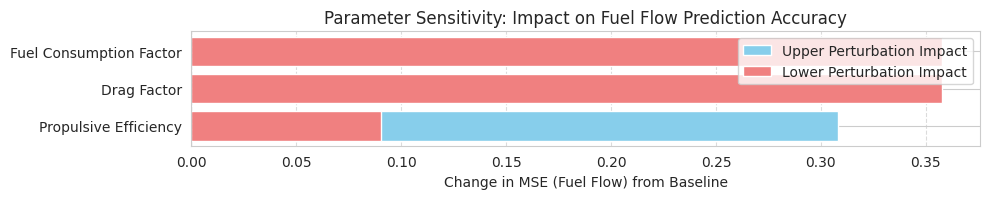

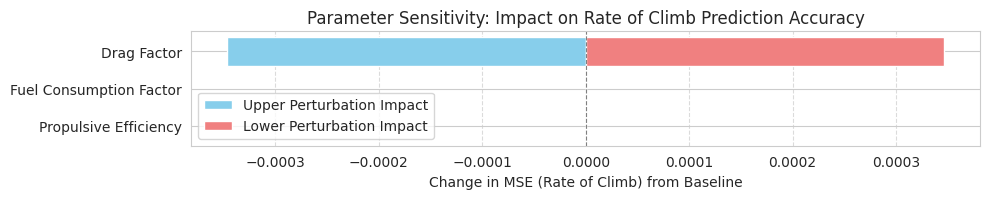

In [ ]:
def plot_tornado_chart(df: pd.DataFrame, title: str, metric_name: str, baseline_mse: float):
    """
    Generates a tornado chart to visualize parameter sensitivity.
    """
    # Calculate the impact of perturbation relative to the baseline MSE
    df['Impact_Lower'] = df['Lower Perturbation MSE'] - baseline_mse
    df['Impact_Upper'] = df['Upper Perturbation MSE'] - baseline_mse

    # Sort by the maximum absolute impact for plotting
    df_sorted = df.reindex(df['Absolute Max MSE Change'].abs().sort_values(ascending=True).index)

    parameters = df_sorted['Parameter']
    impact_lower = df_sorted['Impact_Lower']
    impact_upper = df_sorted['Impact_Upper']

    y_pos = np.arange(len(parameters))

    plt.figure(figsize=(10, 0.7 * len(parameters)))
    plt.barh(y_pos, impact_upper, color='skyblue', label='Upper Perturbation Impact')
    plt.barh(y_pos, impact_lower, color='lightcoral', label='Lower Perturbation Impact')

    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.yticks(y_pos, parameters)
    plt.xlabel(f'Change in {metric_name} from Baseline')
    plt.title(title)
    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot Tornado Chart for Fuel Flow
plot_tornado_chart(
    sensitivity_df_ff,
    'Parameter Sensitivity: Impact on Fuel Flow Prediction Accuracy',
    'MSE (Fuel Flow)',
    mse_ff_baseline_sa
)

# Plot Tornado Chart for Rate of Climb
plot_tornado_chart(
    sensitivity_df_roc,
    'Parameter Sensitivity: Impact on Rate of Climb Prediction Accuracy',
    'MSE (Rate of Climb)',
    mse_roc_baseline_sa
)

# Engineering Observation:
# Tornado grafikleri, model çıktılarının hangi parametrelere en duyarlı olduğunu açıkça göstermektedir. Grafikteki en uzun çubuklar, o parametrenin değerindeki küçük bir değişikliğin model hatasında en büyük değişikliğe neden olduğunu belirtir. Bu, kalibrasyon sırasında veya model iyileştirme çabalarında hangi parametrelerin en çok dikkat edilmesi gerektiğini gösterir. Örneğin, Yakıt Akışı için 'Fuel Consumption Factor' en duyarlı parametre olabilirken, Tırmanma Hızı için 'Propulsive Efficiency' daha kritik olabilir. Bu tür bir analiz, mühendislerin model doğruluğunu artırmak için kaynakları nereye tahsis edecekleri konusunda bilinçli kararlar almasına yardımcı olur ve aynı zamanda ölçüm belirsizliği için öncelikli alanları belirler.

## Sağlamlığı Değerlendirme (Assessing Robustness)

Monte Carlo simülasyonları ve belirsizlik nicelemesi, modelimizin farklı koşullar altındaki sağlamlığını değerlendirmek için vazgeçilmezdir. Bir modelin sadece doğru tahminler yapmakla kalmayıp, aynı zamanda girişlerindeki veya parametrelerindeki değişikliklere karşı ne kadar dayanıklı olduğunu anlamamızı sağlar.

-   **Modelin Güvenilirliği:** Geniş tahmin bantları, modelin tahminlerinin yüksek belirsizlik taşıdığı anlamına gelebilir. Bu, ya modelin kendisinin giriş gürültüsüne karşı hassas olduğunu ya da kalibre edilen parametrelerin hala önemli belirsizliklere sahip olduğunu gösterir.
-   **Karar Verme İçin Bilgi:** Havacılıkta, belirsizlik bilgisi, karar verme süreçlerini doğrudan etkiler. Örneğin, bir uçuş performans tahmini %95 güven aralığı ile sunulduğunda, operasyonel sınırlar veya güvenlik marjları belirlenirken bu aralık dikkate alınabilir.
-   **Model Geliştirme İçin Yön:** Çıktı belirsizliğine en çok katkıda bulunan girdi veya parametrelerin belirlenmesi, mühendislerin model geliştirme veya veri toplama çabalarını nereye odaklayacakları konusunda rehberlik edebilir (örneğin, daha doğru sensörlere yatırım yapmak veya belirli bir parametre için daha fazla kalibrasyon verisi toplamak).

**Mühendislik Yorumu:**

Belirsizlik nicelemesi, uçuş testinden elde edilen modellerin sadece tahmin gücünü değil, aynı zamanda bu tahminlerin içerdiği riski de anlamak için hayati bir araçtır. Uçuş emniyeti, operasyonel planlama ve sertifikasyon süreçlerinde, belirsizliğin kantitatif olarak değerlendirilmesi, daha güvenli ve optimize edilmiş kararlar alınmasına olanak tanır. Monte Carlo, bu karmaşık belirsizliği ele almak için pratik ve etkili bir yol sunar.

# Bölüm 14 – Karar Zekası Perspektifi

Uçuş testi model kalibrasyonunun nihai amacı, mühendislik kararlarını bilgilendirmek ve havacılık operasyonlarında zekayı artırmaktır. Kalibre edilmiş, güvenilir ve belirsizliği nicelenmiş modeller, veri odaklı bir karar alma çerçevesinin temelini oluşturur. Bu bölüm, kalibre edilmiş modellerin çeşitli havacılık alanlarında nasıl paha biçilmez bir araç haline geldiğini ve verinin eyleme dönüştürülebilir içgörülere nasıl dönüştürüldüğünü vurgulamaktadır.

## Kalibre Edilmiş Modeller Nasıl Destek Sağlar?

-   **Uçak Performans Analizi:** Kalibre edilmiş modeller, belirli uçuş koşulları altında uçağın performansını (menzil, dayanıklılık, tırmanma oranı, yakıt tüketimi) doğru bir şekilde tahmin etmek için kullanılır. Bu, operasyonel planlamayı ve filo yönetimini optimize etmeye yardımcı olur.

-   **Uçuş Operasyonları:** Hava yolu şirketleri ve operatörler, uçuş planlaması, yakıt yükü hesaplamaları ve rotalama kararları için kalibre edilmiş performans modellerini kullanır. Bu, operasyonel verimliliği artırır ve maliyetleri düşürür.

-   **Sertifikasyon Faaliyetleri:** Yeni uçak tasarımlarının veya mevcut tasarımlardaki değişikliklerin sertifikasyon süreçleri, model doğrulaması ve güvenilirlik değerlendirmesi için kalibre edilmiş modellerden yoğun bir şekilde yararlanır. Güven aralıklarıyla sunulan tahminler, güvenlik marjlarının belirlenmesinde kritiktir.

-   **Uçuş El Kitabı Geliştirme:** Uçuş el kitaplarındaki (Flight Manual) performans tabloları ve grafikleri, genellikle kalibre edilmiş matematiksel modellerden türetilir. Bu, pilotların güvenli ve verimli uçuş kararları vermeleri için doğru bilgilere sahip olmalarını sağlar.

-   **Gelecek Uçak Tasarımı:** Kalibre edilmiş modellerden elde edilen içgörüler, gelecekteki uçak tasarımlarında iyileştirmeler yapmak için kullanılır. Hangi parametrelerin performansı en çok etkilediği bilgisi (duyarlılık analizi), mühendislik çabalarını optimize etmeye yardımcı olur.

## İş Akışı: Veriden Mühendislik Kararına

Bu not defterinde ele aldığımız tüm adımlar, verimli bir karar zekası döngüsü oluşturur:

1.  **Veri (Data):** Uçuş testlerinden toplanan ham veriler, uçağın gerçek dünya davranışının zengin bir kaydını sunar.

2.  **Model (Model):** Uçağın fiziksel davranışını temsil eden matematiksel bir model oluşturulur (fizik tabanlı veya hibrit).

3.  **Kalibrasyon (Calibration):** Optimizasyon teknikleri kullanılarak modelin bilinmeyen parametreleri, toplanan uçuş verilerine göre ayarlanır. Bu, modelin gerçekliğe en yakın temsilini sağlar.

4.  **Optimizasyon (Optimization):** Kalibrasyon, bir optimizasyon problemidir ve bu süreç, modelin hata oranını en aza indiren parametre setini bulmayı amaçlar. Ancak, daha geniş anlamda, optimize edilmiş bir model, nihai mühendislik kararının optimizasyonunu sağlar.

5.  **Mühendislik Kararı (Engineering Decision):** Kalibre edilmiş ve doğrulanmış modelden elde edilen güvenilir tahminler, duyarlılık ve belirsizlik bilgileriyle birleşerek mühendislerin, operatörlerin ve tasarımcıların bilinçli ve optimize edilmiş kararlar almasını sağlar.

Bu döngü, verilerin sadece toplanması ve analiz edilmesiyle kalmayıp, aynı zamanda eyleme dönüştürülebilir içgörülere dönüştürülerek havacılık sistemlerinin güvenliğini, verimliliğini ve performansını sürekli olarak iyileştirdiği anlamına gelir.

# Bölüm 15 – Sonuç ve Gelecek Çalışmalar

Bu not defteri, uçuş testi verilerini kullanarak uçak modellerinin kalibrasyonu için kapsamlı bir çerçeve sunmuştur. Veri odaklı yaklaşımların gücünü vurgulayarak, fizik tabanlı modellemeyi, optimizasyon tekniklerini, makine öğrenimi destekli hibrit modelleri, belirsizlik nicelemesini ve duyarlılık analizini entegre ettik. Nihai amaç, havacılık mühendisliği kararlarını desteklemek ve operasyonel zekayı artırmaktır.

## Kapsanan Temel Konular:

-   **Sentetik Veri Üretimi ve Keşifsel Analiz:** Kalibrasyon yaklaşımlarımızı test etmek için gerçekçi sentetik uçuş verileri oluşturduk ve bu veriler üzerinde detaylı keşifsel analizler yaparak temel ilişkileri ve potansiyel sorunları belirledik.

-   **Fizik Tabanlı Model Kalibrasyonu:** Bir basitleştirilmiş uçak performans modeli kullanarak, `SciPy.optimize.minimize` ile model parametrelerini kalibre ettik. Kalibrasyonun, modelin tahmin doğruluğunu önemli ölçüde artırdığını ve başlangıçtaki sistematik hataları giderdiğini gösterdik.

-   **Gelişmiş Optimizasyon Yöntemleri:** Farklı optimizasyon algoritmalarını karşılaştırarak (Nelder-Mead, Powell, L-BFGS-B, Differential Evolution), her birinin güçlü ve zayıf yönlerini ve kalibrasyon problemimiz üzerindeki etkilerini tartıştık.

-   **Doğrulama Veri Seti Kullanımı:** Modelin genelleme yeteneğini değerlendirmek için veri setini eğitim ve doğrulama alt kümelerine ayırdık. Kalibre edilmiş modelin, görülmeyen verilerde de başarılı bir performans sergilediğini gösterdik.

-   **Makine Öğrenimi Destekli Kalibrasyon ve Hibrit Modeller:** Random Forest ve Gradient Boosting gibi ML modellerini kullanarak doğrudan tahminler yaptık ve daha sonra fizik modelinin artıklarını modellemek için hibrit bir yaklaşım geliştirdik. Hibrit modellerin, saf fizik veya saf ML modellerine kıyasla artırılmış doğruluk ve sağlamlık sunduğunu vurguladık.

-   **Belirsizlik Nicelemesi (UQ):** Monte Carlo simülasyonlarını kullanarak model girdilerindeki (parametreler ve ölçümler) belirsizliğin model çıktılarına nasıl yansıdığını inceledik. Tahmin bantları ve güven aralıkları oluşturarak model güvenilirliği hakkında kritik bilgiler sağladık.

-   **Duyarlılık Analizi:** Model çıktılarının hangi parametrelere en çok duyarlı olduğunu belirlemek için duyarlılık analizi gerçekleştirdik. Bu analiz, mühendislik çabalarını optimize etmek ve belirsizliğin ana kaynaklarını tespit etmek için değerli içgörüler sunar.

-   **Karar Zekası Perspektifi:** Kalibre edilmiş modellerin havacılıkta uçak performans analizi, operasyonel planlama, sertifikasyon faaliyetleri ve gelecek uçak tasarımı gibi alanlarda nasıl paha biçilmez bir araç haline geldiğini açıkladık. Veriden mühendislik kararına giden iş akışını özetledik.

## Gelecek Çalışmalar ve Araştırma Yönleri:

Bu not defteri, uçuş testi model kalibrasyonuna giriş niteliğinde olup, birçok potansiyel araştırma ve geliştirme alanına kapı aralamaktadır:

1.  **Daha Karmaşık Fizik Modelleri:** Gerçek dünya uygulamaları için daha detaylı ve yüksek doğruluklu aerodinamik, itki ve kütle özellikleri modellerini entegre etmek.

2.  **Gelişmiş Optimizasyon ve UQ Teknikleri:** Bayesyen optimizasyon, Markov Chain Monte Carlo (MCMC) ve Gaussian süreçleri gibi daha gelişmiş teknikleri kullanarak parametre belirsizliğini ve model kalibrasyonunu ele almak.

3.  **Gerçek Uçuş Testi Verileri:** Sentetik veriler yerine gerçek uçuş testlerinden elde edilen, daha yüksek boyutlu ve gürültülü verilerle çalışmak. Bu, veri önişleme ve temizleme tekniklerinin önemini artıracaktır.

4.  **Zamanla Değişen Parametreler ve Adaptif Kalibrasyon:** Uçağın aşınması, yıpranması veya çevresel koşullardaki değişiklikler nedeniyle zamanla değişebilen model parametrelerini ele almak için adaptif kalibrasyon algoritmaları geliştirmek.

5.  **Dinamik Sistem Kalibrasyonu:** Sadece statik performans noktaları yerine, uçağın dinamik tepkilerini (örneğin, kontrol girişlerine yanıtlar) kalibre etmek için yöntemler geliştirmek.

6.  **Sistem Seviyesi Entegrasyon:** Kalibre edilmiş alt sistem modellerini (aerodinamik, itki, iniş takımı vb.) daha büyük bir uçak modeline entegre ederek sistem seviyesi kalibrasyon ve optimizasyon gerçekleştirmek.

7.  **İnsan Faktörü Entegrasyonu:** Pilot davranışları ve operatör kararlarının uçuş performansına etkisini modellemek ve kalibre etmek için yaklaşımlar geliştirmek.

Bu çalışmalar, havacılıkta veri biliminin ve optimizasyonun, güvenliği, verimliliği ve performansı sürekli iyileştirmek için nasıl temel bir rol oynadığını daha da derinleştirecektir. Havacılık endüstrisi, dijitalleşme ve veri odaklı karar verme süreçlerine doğru ilerledikçe, bu tür gelişmiş model kalibrasyon ve doğrulama teknikleri giderek daha kritik hale gelecektir.

---